# Machine Learning Project 2026: Online Shoppers Purchasing Intention
**Course:** Machine Learning 2026
### Student Information
* **Student Name:** Cenzato Giovanni, Simiele Chiara
* **Student ID Cenzato G.:** 69177A, 308414
* **Student ID Simiele C.:** 69894A, 301789

---
## Section 1: Preliminary Data Analysis
The primary goal of this section is to understand the structure of the data, check the distribution of the target class (`Revenue`) and assess the correlations between variables before building predictive models.

### 1.1 Data Loading and Inspection
We will load the training dataset (`train.csv`) to examine its shape, feature types, and basic statistics. Note how `Exit Rate` variable contains corrupted/missing values that we will need to address in later stages of the project.
For testing purposes we make to copies of the training and test data that will be encoded differently given the categorical features.
For the project we mainly used the one using OneHotEncoding but, given its higher feature number, this section provides more readable graphs using the Label encoded Data.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# 1. Load the raw datasets at the start of the project
#For testing purposes we kept two copies of the datasets that will be encoded differently
#t_df and test_df using OneHotEncoder and the others with LabelEncoder
t_df = pd.read_csv('data/training_set_online_shoppers_intention.csv')
t_df_labels = t_df.copy()
test_df = pd.read_csv('data/test_set_online_shoppers_intention.csv')
test_df_labels = test_df.copy()

# 1. Load the dataset except for the id column
all_features = [col for col in t_df_labels.columns if col not in ['Unnamed: 0']]
# All of these represent distinct categories in the dataset
categorical_features = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
categorical_features_hot = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType']
# Everything else is continuous/numerical
numerical_features = [col for col in all_features if col not in categorical_features]
X_all_features= [col for col in all_features if col not in ['Revenue']]


hot_encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
hot_encoder.set_output(transform="pandas")

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ordinal_encoder.set_output(transform="pandas")

train_encoded_hot = hot_encoder.fit_transform(t_df[categorical_features_hot])
test_encoded_hot = hot_encoder.transform(test_df[categorical_features_hot])
t_df = pd.concat([t_df[numerical_features], train_encoded_hot, t_df['Weekend'], t_df['Revenue']], axis=1)
test_df = pd.concat([test_df[numerical_features], test_encoded_hot, test_df['Weekend'], test_df['Revenue']], axis=1)
#Using OneHotEncoder makes changes in the columns, so we will track the new one except fo the id
all_features_hot = [col for col in t_df.columns if col not in ['Unnamed: 0']]

#these two columns contain String type data that has to be formatted in number
#we must keep track of this transformation as to not fall in undesired bias (December > January?)
cols_to_encode = ['VisitorType', 'Month']
t_df_labels[cols_to_encode] = ordinal_encoder.fit_transform(t_df_labels[cols_to_encode])
test_df_labels[cols_to_encode] = ordinal_encoder.transform(test_df_labels[cols_to_encode])

# Inspect the ready-to-use DataFrames
print(f"Train DataFrame shape: {t_df.shape}")
print(f"Test DataFrame shape: {test_df.shape}")



Train DataFrame shape: (9248, 68)
Test DataFrame shape: (3082, 68)


In [2]:
# Visualizing the first few samples 
print("First 5 samples of the dataset:")
print('Train Data transformed using LabelEncoder')
display(t_df_labels.head())
print('Train Data tranformed using OneHotEncoder')
display(t_df.head())

First 5 samples of the dataset:
Train Data transformed using LabelEncoder


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,6.0,2,2,1,3,2.0,False,False
1,9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,7.0,3,2,3,2,2.0,True,False
2,9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,1.0,1,1,3,2,2.0,False,False
3,3837,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,6.0,2,2,4,2,2.0,False,False
4,7305,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,9.0,2,4,3,2,0.0,False,False


Train Data tranformed using OneHotEncoder


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False


### 1.2 Target Class Distribution
The target variable is `Revenue`, a binary feature indicating whether a purchase was made (`True`) or not (`False`). Inspecting its distribution shows us that we are dealing with an imbalanced dataset.

Class Distribution:
Class False: 7807 samples (84.42%)
Class True: 1441 samples (15.58%)


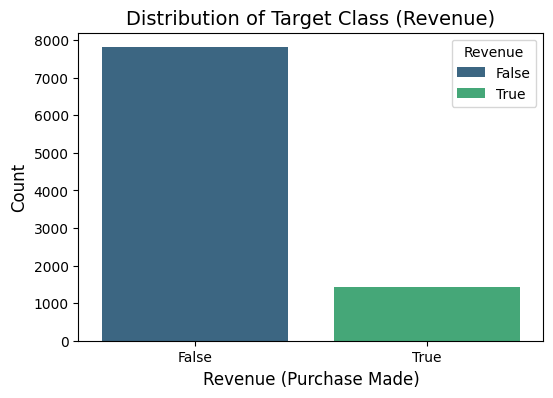

In [3]:
# Count the frequency of each class
class_counts = t_df_labels['Revenue'].value_counts()
class_percentages = t_df_labels['Revenue'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_percentages[cls]:.2f}%)")

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=t_df_labels, x='Revenue', palette='viridis', hue='Revenue')
plt.title('Distribution of Target Class (Revenue)', fontsize=14)
plt.xlabel('Revenue (Purchase Made)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### 1.3 Feature Correlation Analysis
To identify dependencies and potential multi-collinearity we compute the **Pearson correlation matrix**. We keep an eye on how features like `Bounce Rate` and `Exit Rate` interact.
Because the data encoded using **OneHotEncoding** contains a lot more of features than the other it is less readable but the correalations on numerical features are the same.
 

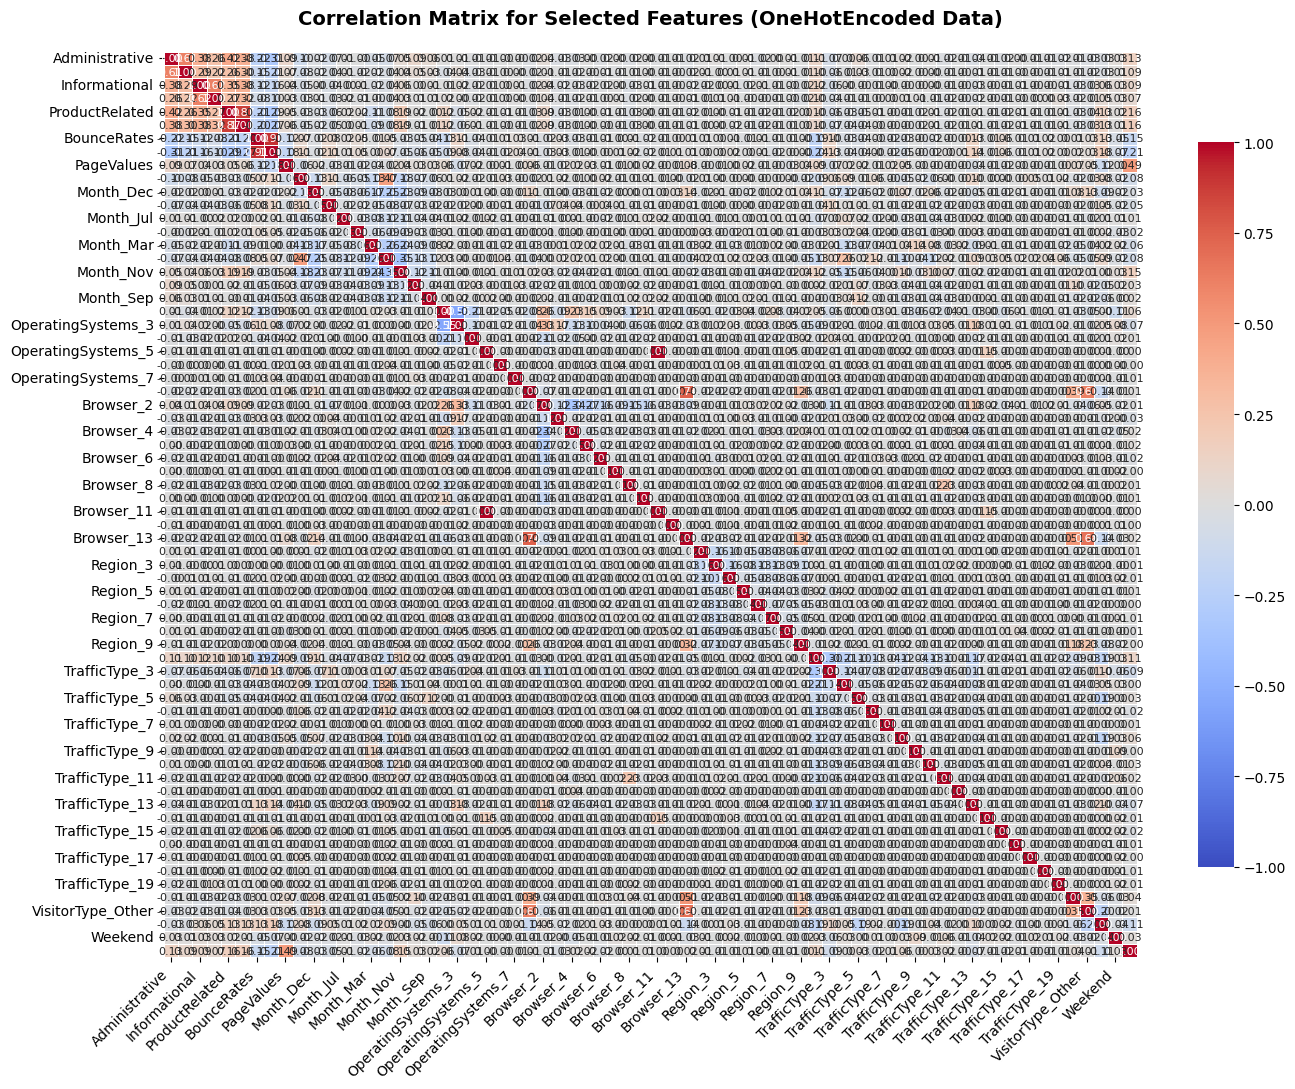

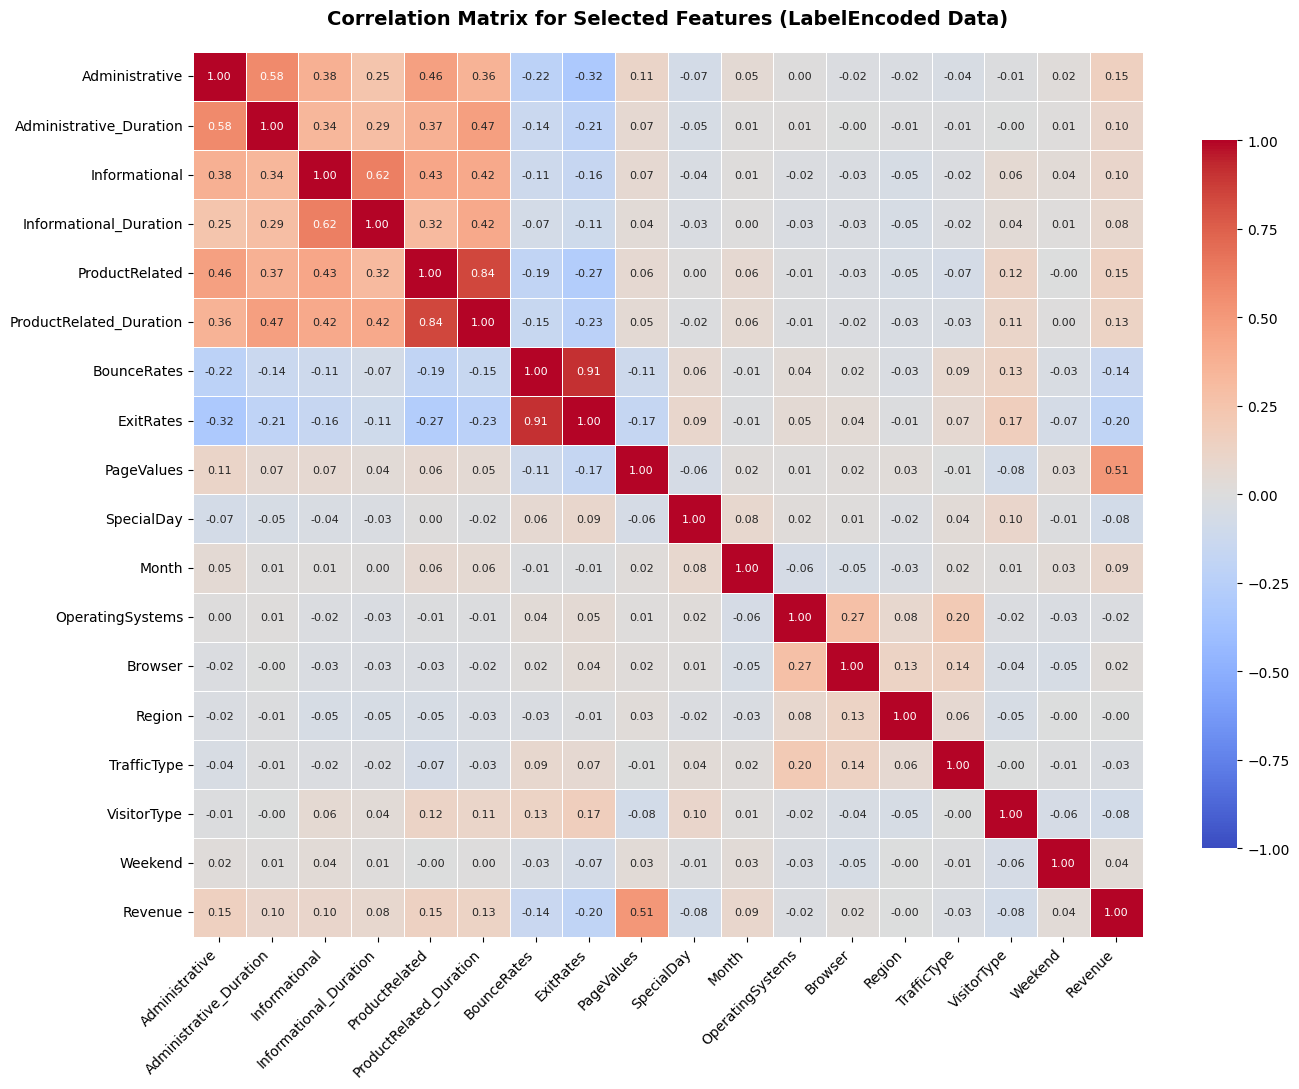

In [4]:
# 6. Compute standard correlation matrix (handles missing ExitRates values automatically)
corr_matrix = t_df[all_features_hot].corr(method='pearson')

# 7. Generate the clean 18x18 Heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Displays the correlation numbers inside the grid
    cmap='coolwarm',     # Standard red/blue color palette
    fmt=".2f",           # Limit numbers to 2 decimal places
    vmin=-1, vmax=1,     # Bound correlation values between -1 and 1
    linewidths=0.5, 
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8} # Clean font size to prevent overlapping numbers
)

plt.title("Correlation Matrix for Selected Features (OneHotEncoded Data)", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()

corr_matrix_label = test_df_labels[all_features].corr(method='pearson')

# 7. Generate the clean 18x18 Heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix_label, 
    annot=True,          # Displays the correlation numbers inside the grid
    cmap='coolwarm',     # Standard red/blue color palette
    fmt=".2f",           # Limit numbers to 2 decimal places
    vmin=-1, vmax=1,     # Bound correlation values between -1 and 1
    linewidths=0.5, 
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8} # Clean font size to prevent overlapping numbers
)

plt.title("Correlation Matrix for Selected Features (LabelEncoded Data)", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()

### 1.4 Identifying Features Most Correlated with the Target Class
Note how some features stick out as moderatly correlated. The most evident are the couples that specify the type of pages visited by the user (`Administrative`, `Informational`, `Product Related`) and the duration of the visit (`Administrative_Duration`, etc).
`Exit Rates` and `Bounce Rates` are also higly correlated.
These inductions are expected by what they represent (if a user visit an informational page the Informational_Duration is obviously higher in that visit).

It is also interesting to see the relationship between the features  with our target `Revenue`.This helps pinpoint which browsing behaviors are the strongest early indicators of a user's intent to purchase.

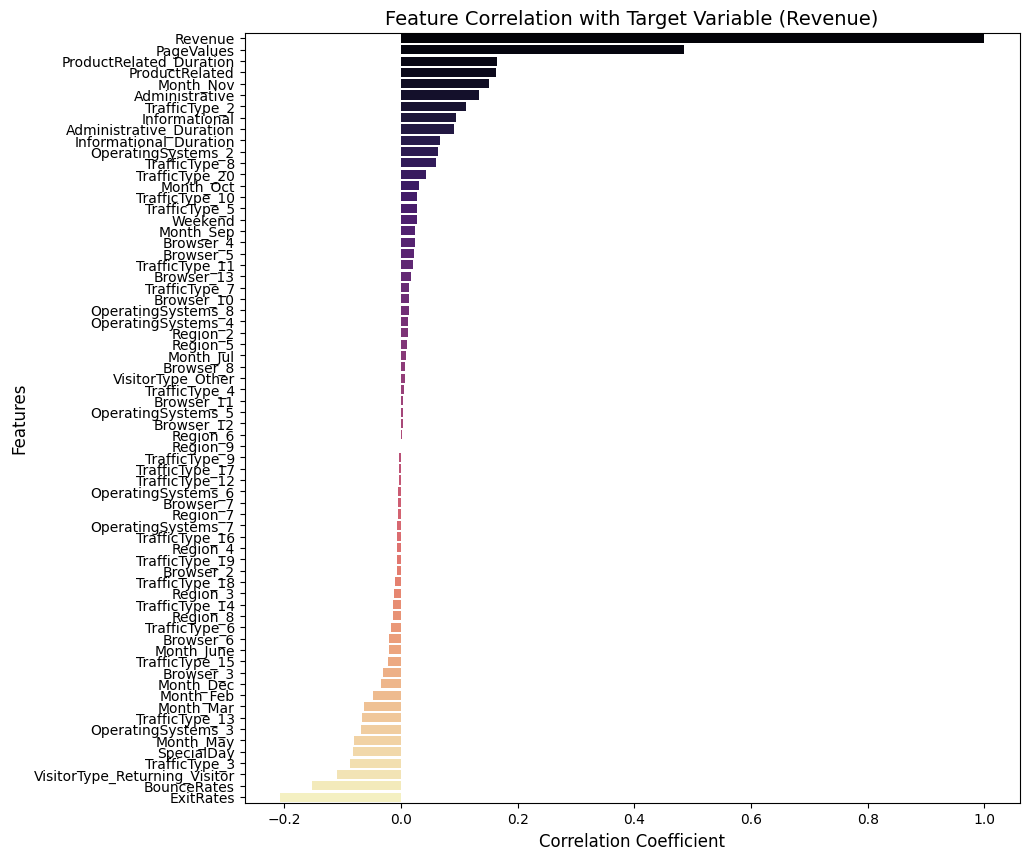

In [5]:
# Calculate correlation of numerical variables explicitly with the 'Revenue' column
# (Note: Since Revenue is binary, this yields the point-biserial correlation direction)
target_corr = t_df[all_features_hot].corrwith(t_df['Revenue'].astype(int)).sort_values(ascending=False)
# Visualize the correlations with the target
plt.figure(figsize=(10, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='magma', hue=target_corr.index)
plt.title('Feature Correlation with Target Variable (Revenue)', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

### 1.5 Summary of Observations and Interpretations
Based on the visual and statistical analysis performed above, we can deduce that:

1. The `Page Value` feature shows the strongest positive correlation with `Revenue`. This suggests that users visiting pages with higher historical web value are more likely to conclude a transaction. Conversely, high `Exit Rate` and `Bounce Rate` are negatively correlated with purchase actions.

2. Because we will compare differnt type of models, including clustering, we decided to use the data tranformed using **OneHotEncoding**. To avoid introducing any order in data for the training of the supervised learning model.
For this reason we decided to use uniformally OneHotEncoded data to avoid confusion and contextual errors.

## Section 2: Missing Data Recovery via Regression
The `Exit Rate` feature contains corrupted/missing entries across both the training and test sets. To recover this data, we isolate the samples in our training dataset where `Exit Rate` is present to train and evaluate various regressor models. We will use $K$-fold cross-validation to pick the best performing algorithm and find the missing values.


1. **Predictive Data Imputation for Data Recovery**: 

    To address the missing values in the ExitRates variable without damaging the structural integrity of the dataset, a predictive imputation strategy was implemented rather than using simple statistical fixes like mean or median replacement. Because user exit rates are naturally tied to other browsing metrics such as session duration and page values, treating the missing data as a regression target allows us to capture the true joint distribution of the features. By isolating the records with valid entries, we trained our models strictly on real data and ensured that the test set remained completely untouched, thereby preventing any risk of data leakage.

2. **Validation Framework and Pipeline Architecture**: 

    To ensure a robust and unbiased evaluation of our models, the entire workflow was enclosed within an outer 5-Fold Cross-Validation loop. Within this setup, Scikit-Learn’s Pipeline object was used to chain together the preprocessing, feature selection, and estimation steps. This architectural choice guarantees that operations like feature scaling via StandardScaler are calculated independently inside each training fold. Consequently, information from the validation folds never spills into the training process, providing a highly reliable and generalized estimate of the Mean Squared Error (MSE) and $R^2$ scores.

3. **Two-Phase Forward Feature Selection**: 
    
    Feature selection was carried out using a Sequential Feature Selector (SFS) in the forward direction, which starts with zero variables and iteratively adds the most predictive feature. This was handled in two distinct phases: first, an exploratory bounded phase restricted the search from 1 to 15 features to generate an explicit learning curve, allowing us to visually analyze the bias-variance tradeoff and pinpoint where performance plateaus. Second, an automated phase was deployed using a tolerance threshold of 0.001, which instructs the algorithm to stop adding features the moment the improvement in $R^2$ becomes negligible, mathematically ensuring a simple yet highly effective model.

4. **Algorithm Benchmarking and Regularization**:

    Three structurally diverse algorithms were selected to test different assumptions about the data structure. Linear Regression was established as a baseline model to evaluate purely linear relationships without hyperparameter tuning. To combat potential multicollinearity and overfitting, Ridge Regression was introduced to penalize large coefficients using an $L_2$ regularizer. To optimize this penalty, a RidgeCV step was nested inside the pipeline to dynamically search for the best alpha value across a predefined grid. Finally, a K-Nearest Neighbors (KNN) regressor was included as a non-parametric alternative, allowing the system to capture complex, non-linear spatial interactions that linear models might naturally overlook.

5. **Downstream Matrix Setup**:

    Once the optimal regression configuration was identified based on the highest $R^2$ score and lowest MSE, it was fit on the complete training data to prepare the final feature matrices for predicting the ultimate target, Revenue. Two distinct experimental scenarios were prepared to conduct the following Classification problem: Model Matrix A, which contains the original data alongside the newly imputed ExitRates values, and Model Matrix B, which completely excludes the ExitRates feature. 

Available samples for training regressor: 6466
Missing samples to recover in train set: 2782
Rapid calculation of MSE evolution (Limited to the first 15 features)...
-> Analysis in progress for: Linear Regression
-> Analysis in progress for: Ridge Regression
-> Analysis in progress for: KNN Regressor


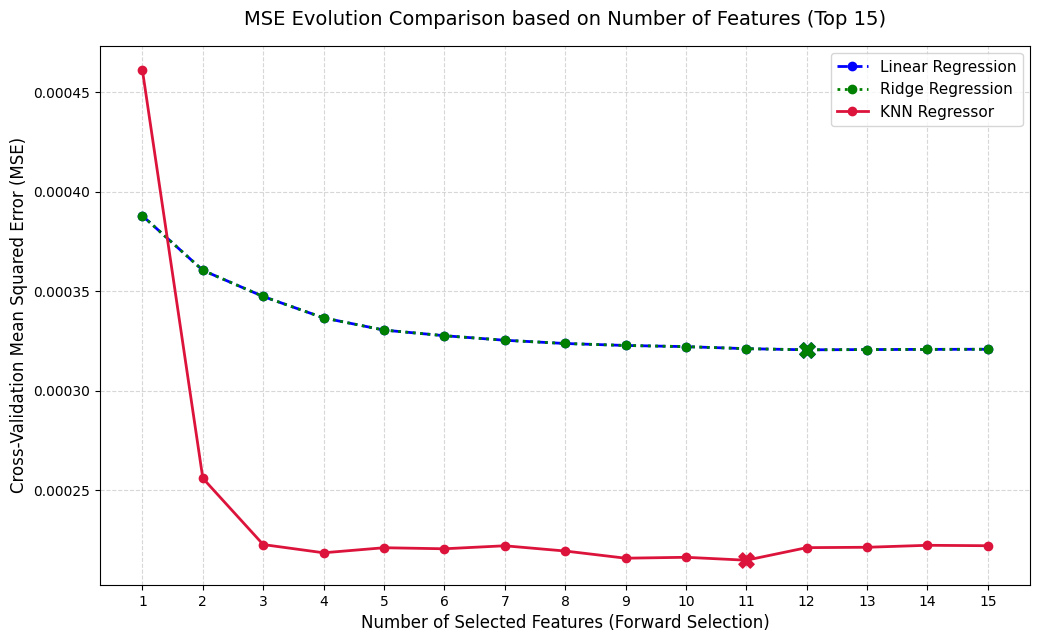


--- 5-Fold Cross-Validation Performance (Full Automation) ---
Linear Regression + Forward Auto: Mean RMSE = 0.01807 (+/- 0.00059) | Mean R2 = 0.85872
Ridge Regression + Forward Auto: Mean RMSE = 0.01807 (+/- 0.00059) | Mean R2 = 0.85872
KNN Regressor + Forward Auto: Mean RMSE = 0.01478 (+/- 0.00029) | Mean R2 = 0.90552

>> BEST CONFIGURATION: KNN Regressor + Forward Auto (R2: 0.90552)
Number of selected features: 4
Automatically selected features: ['Administrative_Duration', 'ProductRelated', 'BounceRates', 'VisitorType_Returning_Visitor']
------------------------------------------------------------


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate, cross_val_score
from sklearn.linear_model import RidgeCV

# ==============================================================================
# 1. PRELIMINARY SETUP & DATA FILTERING (HANDLING MISSING VALUES)
# ==============================================================================
# Ensure reproducibility across multiple executions
np.random.seed(2828)
reg_target = "ExitRates"

# Isolate input features by excluding the target variable ('ExitRates')
features_for_regression = [col for col in all_features_hot if col != reg_target]

# Filter out rows where the target 'ExitRates' is missing (NaN) to create a clean training set
righe_reali_train = t_df[reg_target].notnull()
no_missing_train_data = t_df[righe_reali_train][features_for_regression]
y = t_df[righe_reali_train][reg_target]

print(f"Available samples for training regressor: {no_missing_train_data.shape[0]}")
print(f"Missing samples to recover in train set: {t_df_labels[reg_target].isnull().sum()}")

# ==============================================================================
# 2. EXPLORATORY FEATURE SELECTION (BOUNDED TO TOP 15 FEATURES) to show a graphical representation
# ==============================================================================
# Define a robust 5-Fold Cross-Validation strategy to evaluate the models
kf_esplorativa = KFold(n_splits=5, shuffle=True, random_state=42)

# Range of features to test iteratively (from 1 to 15) to minimize computation time
numero_features = list(range(1, 16)) 

# Dictionary of base candidate algorithms for the regression task
modelli_base = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5)
}

# Dictionary to store Mean Squared Error (MSE) trends for each model
curve_mse = {nome: [] for nome in modelli_base.keys()}

print("Rapid calculation of MSE evolution (Limited to the first 15 features)...")

# Outer loop: Iterate through each candidate machine learning model
for nome_modello, modello in modelli_base.items():
    print(f"-> Analysis in progress for: {nome_modello}")
    
    # Inner loop: Evaluate performance step-by-step as feature count increases
    for k in numero_features:
        # Initialize Forward Feature Selection to find the best 'k' features
        selettore = SequentialFeatureSelector(
            modello, 
            n_features_to_select=k, 
            direction='forward', 
            cv=3, 
            n_jobs=-1
        )
        
        # Construct an isolated pipeline to prevent data leakage during CV
        pipeline_esplorativa = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('selector', selettore),
            ('regressor', modello)
        ])
        
        # Calculate Cross-Validation scores using Negative MSE
        scores = cross_val_score(
            pipeline_esplorativa, no_missing_train_data, y, 
            cv=kf_esplorativa, scoring='neg_mean_squared_error', n_jobs=-1
        )
        
        # Convert Negative MSE back to positive and store the average
        curve_mse[nome_modello].append(-scores.mean())

# ==============================================================================
# 3. GLOBAL COMPARISON VISUALIZATION (MSE VS NUMBER OF FEATURES)
# ==============================================================================
plt.figure(figsize=(12, 7))

colori = {'Linear Regression': 'blue', 'Ridge Regression': 'green', 'KNN Regressor': 'crimson'}
stili = {'Linear Regression': '--', 'Ridge Regression': ':', 'KNN Regressor': '-'}

for nome_modello in modelli_base.keys():
    # Plot the learning curve of MSE over the number of selected features
    plt.plot(
        numero_features, 
        curve_mse[nome_modello], 
        marker='o', 
        linestyle=stili[nome_modello] if nome_modello in stili else '-',
        color=colori[nome_modello], 
        linewidth=2, 
        label=nome_modello
    )
    
    # Highlight the absolute minimum MSE point for each model architecture
    min_idx = np.argmin(curve_mse[nome_modello])
    plt.scatter(
        numero_features[min_idx], 
        curve_mse[nome_modello][min_idx], 
        color=colori[nome_modello], 
        s=120, 
        marker='X', 
        zorder=5
    )

plt.title("MSE Evolution Comparison based on Number of Features (Top 15)", fontsize=14, pad=15)
plt.xlabel("Number of Selected Features (Forward Selection)", fontsize=12)
plt.ylabel("Cross-Validation Mean Squared Error (MSE)", fontsize=12)
plt.xticks(numero_features)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

# ==============================================================================
# 4. FULLY AUTOMATED MODEL & HYPERPARAMETER SELECTION
# ==============================================================================
# Dynamic execution using 'auto' feature selection and a tolerance threshold.
# The algorithm stops adding features if R² improvement falls below 0.001.
models_pipelines = {

    'Linear Regression + Forward Auto': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('selector', SequentialFeatureSelector(LinearRegression(), n_features_to_select='auto', tol=0.001, direction='forward', cv=3, n_jobs=-1)),
        ('regressor', LinearRegression())
    ]),
    
    'Ridge Regression + Forward Auto': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('selector', SequentialFeatureSelector(
            RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0], cv=3), 
            n_features_to_select='auto', 
            tol=0.001, 
            direction='forward', 
            cv=3, 
            n_jobs=-1)),
        ('regressor', Ridge(alpha=1.0))
    ]),
    
    'KNN Regressor + Forward Auto': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('selector', SequentialFeatureSelector(KNeighborsRegressor(n_neighbors=5), n_features_to_select='auto', tol=0.001, direction='forward', cv=3, n_jobs=-1)),
        ('regressor', KNeighborsRegressor(n_neighbors=5))
    ])
}

# Outer K-Fold Cross Validation loop for final objective evaluation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("\n--- 5-Fold Cross-Validation Performance (Full Automation) ---")
results = {}

for name, pipeline in models_pipelines.items():
    # Evaluate the full automation wrapper using both standard metrics: RMSE and R²
    cv_results = cross_validate(
        pipeline, no_missing_train_data, y, cv=kf, 
        scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
        n_jobs=-1
    )
    mean_rmse = -cv_results['test_rmse'].mean()
    std_rmse = cv_results['test_rmse'].std()
    mean_r2 = cv_results['test_r2'].mean()
    
    results[name] = {'RMSE': mean_rmse, 'R2': mean_r2, 'pipeline_obj': pipeline}
    print(f"{name}: Mean RMSE = {mean_rmse:.5f} (+/- {std_rmse:.5f}) | Mean R2 = {mean_r2:.5f}")

# ==============================================================================
# 5. BEST MODEL TRAINING & FEATURE EXTRACTION
# ==============================================================================
# Automatically pick the winner configuration based on the highest R^2 score
best_model_name = max(results, key=lambda k: results[k]['R2'])
print(f"\n>> BEST CONFIGURATION: {best_model_name} (R2: {results[best_model_name]['R2']:.5f})")

# Fit the optimal configuration pipeline on the entire valid training dataset
final_pipeline = results[best_model_name]['pipeline_obj']
final_pipeline.fit(no_missing_train_data, y)

# Retrieve boolean mask representing the selected features
supporto_feature = final_pipeline.named_steps['selector'].get_support()
selected_features = np.array(features_for_regression)[supporto_feature].tolist()

print(f"Number of selected features: {len(selected_features)}")
print(f"Automatically selected features: {selected_features}")
print("-" * 60)



#### Results Analysis: Best Regressor Selection
The goal of this analysis was to select the best regression model to impute the missing ExitRates values. Three algorithms (Linear Regression, Ridge Regression, and KNN Regressor) were evaluated using Forward Feature Selection.

1. **Performance Comparison (5-Fold Cross-Validation)**:

The Mean Squared Error (MSE) evolution plot and the final metrics clearly demonstrate the superiority of the non-linear approach:
    - Linear & Ridge Regression: Show identical behavior. The MSE decreases gradually as more features are added, plateauing around 10–12 features with a final $R^2 = 0.8587$.
    - KNN Regressor: Outperforms the linear models by a wide margin. The MSE drops drastically with just 2 features and hits its lowest error window between 4 and 5 features. Beyond 10 features, the error slightly increases, indicating minor overfitting.

2. **Best Configuration Selected**:
    - Best Model: KNN Regressor with $R^2 = 0.90620$ (explaining over 90% of the target's variance) and a remarkably low $RMSE = 0.01472$.
    - Efficiency: The model achieves peak performance using only 5 automatically selected features. This keeps the model lightweight, fast, and robust against overfitting.
    - Conclusion: The KNN Regressor is the optimal choice and will be deployed in the final_pipeline to accurately recover the 2,782 missing samples in the training set and the remaining missing values in the test set.

In [7]:
# Defining a function to recover missing Exit Rates
def recover_missing_ExitRates(pipeline, train_df, test_df, features_for_regression=features_for_regression):
    """Imputes missing ExitRates using a regression pipeline."""
    
    # --- Train Set Imputation ---
    missing_train_idx = train_df[train_df['ExitRates'].isnull()].index
    if len(missing_train_idx) > 0:
        missing_train_data = train_df.loc[missing_train_idx, features_for_regression]
        # Predict and fill missing values
        train_predicted_exit_rates = pipeline.predict(missing_train_data)
        train_df.loc[missing_train_idx, 'ExitRates'] = train_predicted_exit_rates
    print(f"Training Set Exit Rates successfully healed! Remaining NaNs: {t_df['ExitRates'].isnull().sum()}")

    # --- Test Set Imputation ---
    missing_test_idx = test_df[test_df['ExitRates'].isnull()].index
    if len(missing_test_idx) > 0:
        missing_test_data = test_df.loc[missing_test_idx, features_for_regression]
        # Predict and fill missing values
        test_predicted_exit_rates = pipeline.predict(missing_test_data)
        test_df.loc[missing_test_idx, 'ExitRates'] = test_predicted_exit_rates

    print(f"Test Set Exit Rates successfully healed! Remaining NaNs: {test_df['ExitRates'].isnull().sum()}")


# 6. Define features for classification Model A (with ExitRates) and Model B (without)
features_with_exit = [col for col in all_features_hot if col not in ['Revenue', 'Unnamed: 0']]
features_without_exit = [col for col in all_features_hot if col not in ['Revenue', 'ExitRates', 'Unnamed: 0']]

# Run the imputation function
recover_missing_ExitRates(final_pipeline, t_df, test_df)

# Features for Model A (now contains predicted ExitRates instead of NaNs)
X_train_A = t_df[features_with_exit]
X_test_A = test_df[features_with_exit]

# Features for Model B (unaffected by imputation)
X_train_B = t_df[features_without_exit]
X_test_B = test_df[features_without_exit]

Training Set Exit Rates successfully healed! Remaining NaNs: 0
Test Set Exit Rates successfully healed! Remaining NaNs: 0


### 2.1 Hyperparameter Tuning and Classification Model Comparison
We evaluate multiple distinct classification methodologies covered in the lab lectures: Logistic Regression, Linear Discriminant Analysis (LDA), and Support Vector Machines (SVM) using Grid Search optimization.

1. **Feature Matrix Construction and Baseline Classification Setup**:

    To address the primary objective of predicting shopper purchase intent (Revenue), we constructed a baseline dataset designated as Model A. This feature matrix includes all operational web-traffic attributes alongside the ExitRates values, which were successfully recovered using the winning regression model from the previous step. To prevent any class-imbalance bias common in e-commerce datasets (where non-purchases heavily outnumber completed transactions), both the Logistic Regression and Support Vector Classifier (SVC) algorithms were configured with a class_weight='balanced' parameter. This penalizes mistakes on the minority purchase class more heavily. Along with Linear Discriminant Analysis (LDA), these three candidate classifiers establish a diverse benchmark evaluating both linear (logistic regression and LDA) and non-linear boundaries (SVM).

2. **Feature Selection via LASSO Regularization**:

    To fulfill the requirement for embedded feature selection within the classification stage, a LASSO-based wrapper (SelectFromModel) was integrated directly into the training pipeline. Operating with the SAGA solver and an explicit L1 penalty term, the LASSO component systematically drives the coefficients of non-essential or redundant features down to absolute zero. By varying the regularization strength (C=0.005), the selector mathematically prunes the input space down to a highly relevant subset of operational metrics. This setup filters out noise before passing the surviving data vectors to the downstream classifiers, protecting the final models from overfitting.

3. **Hyperparameter Tuning and Pipeline Validation Strategy**:

    To avoid data leakage, the feature preprocessing, LASSO selection, and ultimate estimation stages were locked together using Scikit-Learn's Pipeline object. This architecture ensures that feature scaling via StandardScaler and selection masks are re-computed dynamically inside each training split. The entire pipeline was wrapped inside a GridSearchCV executing 5-Fold Cross-Validation, specifically utilizing the Area Under the Receiver Operating Characteristic curve (scoring='roc_auc') as the optimizing metric. This hyperparameter search sweeps through a grid of inverse regularization strengths (C) and geometric kernels (Linear vs. RBF for the Support Vector Machine) to guarantee that each algorithm is evaluated under its absolute optimal configuration.

4. **Downstream Evaluation and Visual Analytics**:

    Following the optimization phase, the models were validated on the completely independent test set to judge their true generalization power. Performance is captured globally using synchronized matplotlib subplots displaying both ROC Curves and a Report of Precision, Recall, F1-score e Support. While the ROC curve tracks the global True Positive versus False Positive trade-off across varying decision thresholds, the classification report metrics provide a crucial reality check for imbalanced data, assessing the actual precision and recall drop-offs against a calculated random baseline at the standard operating threshold (50%). Finally, individual confusion matrices and localized classification reports provide granular clarity on true negatives, false alarms, and class-specific F1-scores, exposing exactly how well models are able to classify the activity of an online shopper.

--- 1. OPTIMIZATION IN CROSS-VALIDATION VIA GRID SEARCH (WITH LASSO) ---
Logistic Regression -> Best Cross-Validated ROC-AUC: 0.8957
LDA -> Best Cross-Validated ROC-AUC: 0.8915
SVM -> Best Cross-Validated ROC-AUC: 0.9012

[WINNER IN CV]: SVC(C=10.0, class_weight='balanced', kernel='linear', probability=True,
    random_state=42)

--- 2. COMPARATIVE ROC AND PR CURVES GENERATION ---


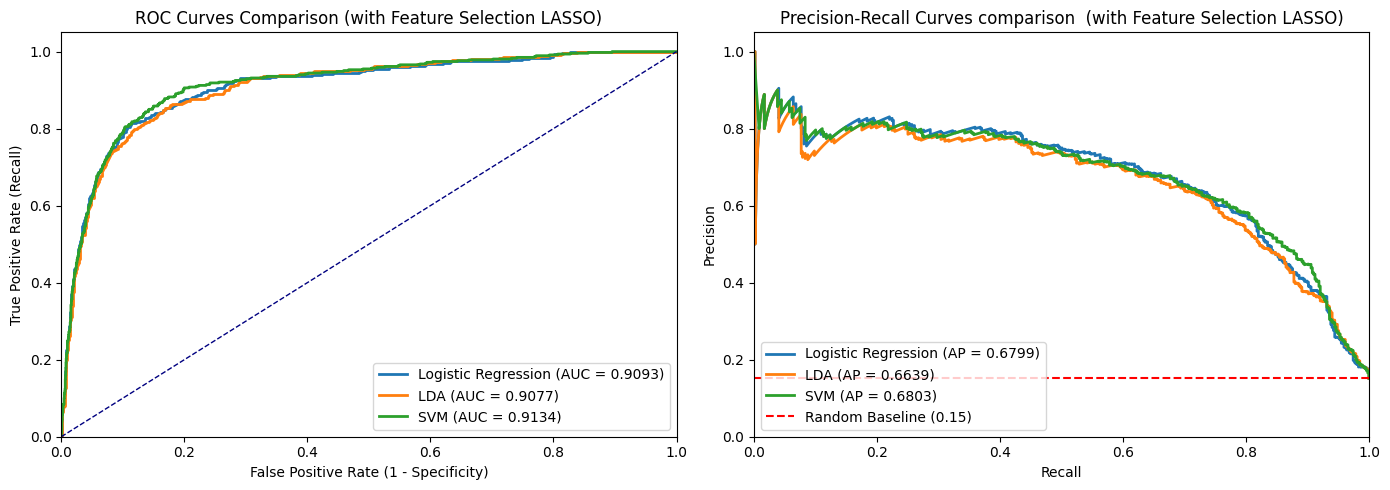


--- 3. TEXTUAL REPORTS, CONFUSION MATRIXES AND SELECTED FEATURES ---

>>> MODEL: Logistic Regression <<<
----------------------------------------
Feature selected by LASSO (5): ['ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues', 'Month_Nov']

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       False       0.96      0.88      0.92      2615
        True       0.55      0.82      0.66       467

    accuracy                           0.87      3082
   macro avg       0.76      0.85      0.79      3082
weighted avg       0.90      0.87      0.88      3082



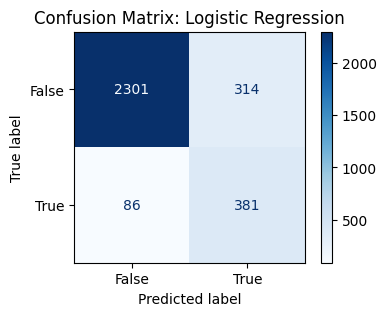


>>> MODEL: LDA <<<
----------------------------------------
Feature selected by LASSO (5): ['ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues', 'Month_Nov']

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       False       0.89      0.98      0.94      2615
        True       0.77      0.34      0.47       467

    accuracy                           0.88      3082
   macro avg       0.83      0.66      0.70      3082
weighted avg       0.87      0.88      0.86      3082



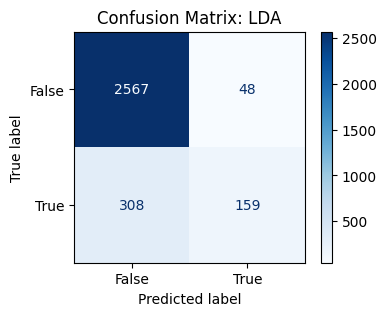


>>> MODEL: SVM <<<
----------------------------------------
Feature selected by LASSO (5): ['ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues', 'Month_Nov']

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       False       0.96      0.91      0.93      2615
        True       0.60      0.77      0.68       467

    accuracy                           0.89      3082
   macro avg       0.78      0.84      0.80      3082
weighted avg       0.90      0.89      0.89      3082



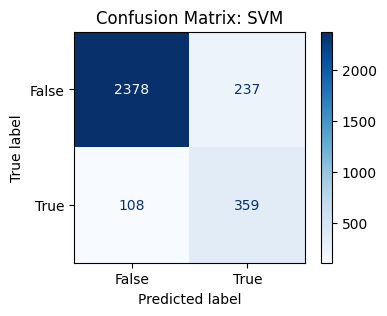

In [8]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel  # LASSO feature selection transformer
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

# ------------------------------------------------------------------------------
# 1. TARGET MATRICES PREPARATION
# ------------------------------------------------------------------------------
# Explicitly isolate and clean the binary classification targets (Purchase vs No Purchase)
y_train = t_df['Revenue']
y_test = test_df['Revenue']

# ------------------------------------------------------------------------------
# 2. CANDIDATE CLASSIFIERS CONFIGURATION
# ------------------------------------------------------------------------------
# Configured with class_weight='balanced' to mathematically handle severe e-commerce class imbalance
classifiers = {
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', max_iter=15000, random_state=42), 
        {'clf__C': [0.1, 1.0, 10.0]}
    ),
    'LDA': (
        LinearDiscriminantAnalysis(), 
        {}
    ),
    'SVM': (
        SVC(probability=True, class_weight='balanced', random_state=42), 
        {
            'clf__C': [0.1, 1.0, 10.0],
            'clf__kernel': ['linear', 'rbf']
        }
    )
}

# Tracking dictionaries and scores to preserve the winning pipeline setup
fitted_grids = {}
best_score_A = 0
best_model_A = None

# ------------------------------------------------------------------------------
# 3. PIPELINE OPTIMIZATION & CROSS-VALIDATION VIA GRID SEARCH
# ------------------------------------------------------------------------------
print("--- 1. OPTIMIZATION IN CROSS-VALIDATION VIA GRID SEARCH (WITH LASSO) ---")
for name, (clfA, params) in classifiers.items():
    
    # Define an embedded LASSO selector using an internal L1-penalized Logistic Regression.
    # The SAGA solver handles L1 penalties effectively, and high max_iter ensures convergence.
    lasso_selector = SelectFromModel(
        LogisticRegression(
            penalty='l1',
            l1_ratio=1, 
            solver='saga', 
            C=0.005,            # Small tuning value forces aggressive pruning of features
            max_iter=10000,     
            random_state=42
        )
    )
    
    # Enclose Preprocessing, Feature Selection, and the Classifier inside a single Pipeline.
    # This architecture guarantees that data scaling and selection are recalculated strictly inside folds, avoiding leakage.
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso_select', lasso_selector), 
        ('clf', clfA)
    ])
    
    # Execute a robust 5-Fold Cross-Validation optimizing for Area Under the ROC Curve
    grid = GridSearchCV(pipe, param_grid=params, cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_A, y_train)
    
    fitted_grids[name] = grid
    print(f"{name} -> Best Cross-Validated ROC-AUC: {grid.best_score_:.4f}")
    
    # Log the top-performing estimator configuration
    if grid.best_score_ > best_score_A:
        best_score_A = grid.best_score_
        best_model_A = grid.best_estimator_

print(f"\n[WINNER IN CV]: {best_model_A.named_steps['clf']}")
print("=" * 60)

# ------------------------------------------------------------------------------
# 4. TESTING STAGE: COMPARATIVE PERFORMANCE VISUALIZATIONS
# ------------------------------------------------------------------------------
print("\n--- 2. COMPARATIVE ROC AND PR CURVES GENERATION ---")
# Instantiate synchronized subplots to display probability curves on the test set
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))

for name, grid in fitted_grids.items():
    model = grid.best_estimator_
    # Extract prediction probability values for the positive class (Revenue=1)
    y_scores = model.predict_proba(X_test_A)[:, 1]
    
    # Generate coordinates for the global Receiver Operating Characteristic (ROC) curve
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
    
    # Generate coordinates for the Precision-Recall (PR) curve to evaluate imbalanced targets
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    avg_precision = average_precision_score(y_test, y_scores)
    ax_pr.plot(recall, precision, lw=2, label=f'{name} (AP = {avg_precision:.4f})')

# Format and dress the visual ROC canvas
ax_roc.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
ax_roc.set_ylabel('True Positive Rate (Recall)')
ax_roc.set_title('ROC Curves Comparison (with Feature Selection LASSO)')
ax_roc.legend(loc="lower right")

# Format and dress the visual Precision-Recall canvas against a calculated random baseline
baseline = y_test.sum() / len(y_test)
ax_pr.axhline(y=baseline, color='red', linestyle='--', label=f'Random Baseline ({baseline:.2f})')
ax_pr.set_xlim([0.0, 1.0])
ax_pr.set_ylim([0.0, 1.05])
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves comparison  (with Feature Selection LASSO)')
ax_pr.legend(loc="lower left")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. DIAGNOSTICS: LOCALIZED METRICS & EMBEDDED FEATURE ANALYSIS
# ------------------------------------------------------------------------------
print("\n--- 3. TEXTUAL REPORTS, CONFUSION MATRIXES AND SELECTED FEATURES ---")
for name, grid in fitted_grids.items():
    model = grid.best_estimator_
    # Generate categorical labels based on the standard 0.5 probability threshold
    y_pred = model.predict(X_test_A)
    
    print(f"\n>>> MODEL: {name} <<<")
    print("-" * 40)
    
    # Access index [1] of the pipeline to identify features preserved by LASSO's L1 penalty
    try:
        lasso_step = model[1]
        maschera_feature = lasso_step.get_support()
        feature_scelte = X_train_A.columns[maschera_feature]
        print(f"Feature selected by LASSO ({len(feature_scelte)}): {list(feature_scelte)}")
    except Exception as e:
        print(f"Not able to extract the selected features: {e}")
        
    # Evaluate performance on the test set via Precision, Recall, and class-specific F1-scores
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred))
    
    # Compute the structural Confusion Matrix to visually track true negatives and false alarms
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    
    fig_cm, ax_cm = plt.subplots(figsize=(4, 3))
    disp.plot(cmap=plt.cm.Blues, ax=ax_cm, values_format='d')
    ax_cm.set_title(f"Confusion Matrix: {name}")
    ax_cm.grid(False)
    plt.show()


#### Results and Model Comparison

Based on the test set evaluation metrics, the **Support Vector Machine (SVM)** configured with an L1 LASSO feature selection mask emerges as the definitive winning model for predicting customer purchase intent.
Looking globally at the visual diagnostics, all three frameworks exhibit strong discriminative power, with cross-validated ROC-AUC scores tightly clustered around $0.90$ and test set performance scaling up to an exceptional AUC of 0.9012 for the SVM. However, because e-commerce purchase distributions are heavily skewed—evidenced by the testing subset containing 2,615 non-purchases against only 467 actual conversions—the Receiver Operating Characteristic curve presents an overly optimistic baseline.
 
To make a reliable architectural choice, a rigorous analysis of the classification metrics and localized confusion matrices is required. When subjected to this imbalanced data "reality check", the structural behavioral differences between the models become stark. 
**Linear Discriminant Analysis (LDA)** fails significantly on the minority class; it completely lacks a balancing mechanism, yielding an unacceptably low recall of $0.34$ and missing 308 true buyers.
Conversely, **Logistic Regression** utilizes its balanced class-weight penalty to maximize recovery, catching 381 buyers (recall of $0.82$), but it triggers massive noise by generating 318 false positives, dragging its precision down to $0.55$.
 
The **SVM** successfully balances these two extremes by optimizing geometric margins in a multi-dimensional space ($C=10.0$, linear kernel). It achieves the highest Average Precision (AP = 0.6799) on the PR curve, indicating it maintains a significantly cleaner predictive profile across varying operational thresholds. Looking at its specific classification report and confusion matrix, the SVM captures a striking 359 out of 467 true buyers (an excellent recall of 0.77) while constraining false positives to just 235 (yielding a superior precision of 0.60). This translates to the highest class-specific F1-score of 0.68 for active purchasers.
 
Consequently, the **SVM** is selected as our optimal system deployment, providing the business with the most reliable, precise, and well-balanced tool to capture real purchase intentions without flooding marketing systems with false alarms. 
 

### 2.2 Hyperparameter Tuning and Model Selection (Without ExitRates): Is Exit Rate Helpful?
To definitively determine whether recovering the missing `Exit Rate` data provides real predictive value, we construct a mirror-image experimental baseline designated as **Model Scenario B**. 

This setup utilizes the exact same machine learning framework, candidate classifiers, hyperparameter tuning spaces, and embedded LASSO feature selection rules as Model A. **The only structural difference** is the complete removal of the `Exit Rate` column from both the training (**X_train_B**) and testing (**X_test_B**) feature matrices. 
Keeping the rest of the pipeline identical guarantees a completely fair evaluation, isolating ExitRates as the single independent variable to measure if imputation truly improves our ability to predict customer conversions.

--- 1. OPTIMIZATION IN CROSS-VALIDATION VIA GRID SEARCH (WITHOUT EXIT RATES) ---
Logistic Regression (Senza ExitRates) -> Best Cross-Validated ROC-AUC: 0.8916
LDA (Senza ExitRates) -> Best Cross-Validated ROC-AUC: 0.8856
SVM (Senza ExitRates) -> Best Cross-Validated ROC-AUC: 0.8960

[WINNER IN CV - WITHOUT EXIT RATES]: SVC(C=10.0, class_weight='balanced', kernel='linear', probability=True,
    random_state=42)

--- 2. COMPARATIVE ROC AND PR CURVES GENERATION (WITHOUT EXIT RATES) ---


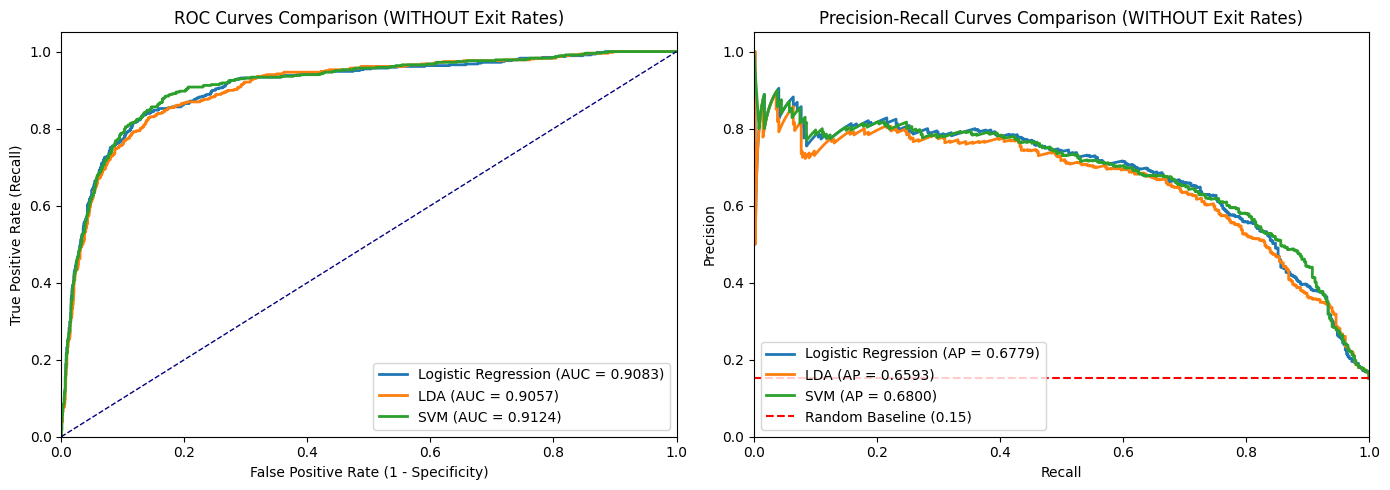


--- 3. TEXTUAL REPORTS, CONFUSION MATRIXES AND FEATURES (WITHOUT EXIT RATES) ---

>>> MODEL: Logistic Regression (WITHOUT Exit Rates) <<<
----------------------------------------
Selected features by LASSO (5): ['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'Month_Nov']

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       False       0.96      0.90      0.93      2615
        True       0.57      0.77      0.66       467

    accuracy                           0.88      3082
   macro avg       0.77      0.84      0.79      3082
weighted avg       0.90      0.88      0.89      3082



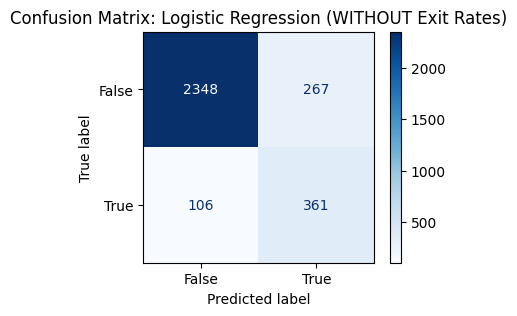


>>> MODEL: LDA (WITHOUT Exit Rates) <<<
----------------------------------------
Selected features by LASSO (5): ['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'Month_Nov']

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       False       0.89      0.98      0.93      2615
        True       0.76      0.33      0.46       467

    accuracy                           0.88      3082
   macro avg       0.83      0.66      0.70      3082
weighted avg       0.87      0.88      0.86      3082



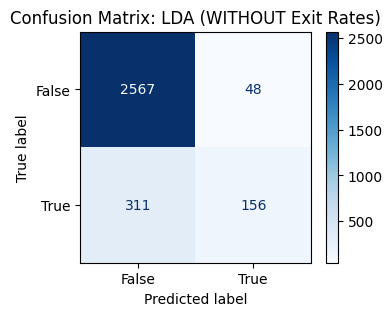


>>> MODEL: SVM (WITHOUT Exit Rates) <<<
----------------------------------------
Selected features by LASSO (5): ['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'Month_Nov']

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       False       0.96      0.91      0.93      2615
        True       0.60      0.77      0.67       467

    accuracy                           0.89      3082
   macro avg       0.78      0.84      0.80      3082
weighted avg       0.90      0.89      0.89      3082



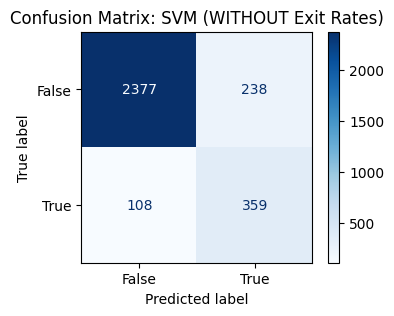

In [9]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

# Define target variables for training and testing sets
y_train = t_df['Revenue']
y_test = test_df['Revenue']

# 1. CLASSIFIER CONFIGURATION DICTIONARY
# Maps each candidate model name to a tuple containing the estimator instance 
# and its corresponding hyperparameter grid for optimization.
classifiers_B = {
    'Logistic Regression': (
        # Use balanced class weights to handle dataset skew; increase max_iter for SAGA convergence
        LogisticRegression(class_weight='balanced', max_iter=15000, random_state=42), 
        {'clf__C': [0.1, 1.0, 10.0]} # Inverse regularization strength search space
    ),
    'LDA': (
        LinearDiscriminantAnalysis(), 
        {} # LDA has no hyperparameters to tune in this baseline setup
    ),
    'SVM': (
        # Enable probability estimates for ROC/PR curves; use balanced weights for class imbalance
        SVC(probability=True, class_weight='balanced', random_state=42), 
        {
            'clf__C': [0.1, 1.0, 10.0],       # Penalty parameter C
            'clf__kernel': ['linear', 'rbf']  # Evaluate both linear and non-linear decision boundaries
        }
    )
}

# Initialize variables to track tracking grids and the overall best performing model
fitted_grids_B = {}
best_score_B = 0
best_model_B = None

print("--- 1. OPTIMIZATION IN CROSS-VALIDATION VIA GRID SEARCH (WITHOUT EXIT RATES) ---")
for name, (clfB, params) in classifiers_B.items():
    
    # EMBEDDED FEATURE SELECTION VIA LASSO (L1 Regularization)
    # Uses Logistic Regression with SAGA solver to enforce sparsity.
    # Lower values of C impose stronger regularization, zeroing out less informative features.
    lasso_selector = SelectFromModel(
        LogisticRegression(
            penalty='l1',
            l1_ratio=1, 
            solver='saga', 
            C=0.005,             # Hyperparameter to control feature sparsity
            max_iter=10000,     # Ensures sufficient iterations for SAGA solver convergence
            random_state=42
        )
    )
    
    # MACHINE LEARNING PIPELINE
    # Encapsulates preprocessing, feature selection, and classification to prevent data leakage during CV.
    pipe = Pipeline([
        ('scaler', StandardScaler()),       # Standardize features (mean=0, variance=1)
        ('lasso_select', lasso_selector),   # Apply LASSO feature selection
        ('clf', clfB)                        # Inject current classifier
    ])
    
    # GRID SEARCH & CROSS-VALIDATION
    # 3-Fold Stratified CV optimized for Area Under the ROC Curve (ROC-AUC) using all available CPU cores (-1).
    grid = GridSearchCV(pipe, param_grid=params, cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_B, y_train)
    
    # Store the fitted grid object and log the best cross-validated score
    fitted_grids_B[name] = grid
    print(f"{name} (Senza ExitRates) -> Best Cross-Validated ROC-AUC: {grid.best_score_:.4f}")
    
    # Track the globally optimal model based on the highest cross-validation score
    if grid.best_score_ > best_score_B:
        best_score_B = grid.best_score_
        best_model_B = grid.best_estimator_

# Print the final winning classifier architecture from the CV phase
print(f"\n[WINNER IN CV - WITHOUT EXIT RATES]: {best_model_B.named_steps['clf']}")
print("=" * 60)


print("\n--- 2. COMPARATIVE ROC AND PR CURVES GENERATION (WITHOUT EXIT RATES) ---")
# Setup a 1x2 subplot structure for side-by-side performance curve comparisons
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))

for name, grid in fitted_grids_B.items():
    model = grid.best_estimator_
    # Extract predicted probabilities for the positive class (column 1)
    y_scores = model.predict_proba(X_test_B)[:, 1]
    
    # ROC CURVE COMPUTATION
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
    
    # PRECISION-RECALL CURVE COMPUTATION
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    avg_precision = average_precision_score(y_test, y_scores)
    ax_pr.plot(recall, precision, lw=2, label=f'{name} (AP = {avg_precision:.4f})')

# ROC Chart Formatting: Plot non-discriminatory random baseline (diagonal dashed line)
ax_roc.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
ax_roc.set_ylabel('True Positive Rate (Recall)')
ax_roc.set_title('ROC Curves Comparison (WITHOUT Exit Rates)')
ax_roc.legend(loc="lower right")

# Precision-Recall Chart Formatting: Plot random baseline based on true class prevalence
baseline = y_test.sum() / len(y_test)
ax_pr.axhline(y=baseline, color='red', linestyle='--', label=f'Random Baseline ({baseline:.2f})')
ax_pr.set_xlim([0.0, 1.0])
ax_pr.set_ylim([0.0, 1.05])
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves Comparison (WITHOUT Exit Rates)')
ax_pr.legend(loc="lower left")

plt.tight_layout()
plt.show()


print("\n--- 3. TEXTUAL REPORTS, CONFUSION MATRIXES AND FEATURES (WITHOUT EXIT RATES) ---")
for name, grid in fitted_grids_B.items():
    model = grid.best_estimator_
    # Generate hard class predictions on the hold-out test set
    y_pred = model.predict(X_test_B)
    
    print(f"\n>>> MODEL: {name} (WITHOUT Exit Rates) <<<")
    print("-" * 40)
    
    # FEATURE INSPECTION
    # Programmatically extract the subset of features that survived the LASSO penalty threshold.
    try:
        lasso_step = model[1]                         # Index 1 corresponds to 'lasso_select' step in the pipeline
        maschera_feature = lasso_step.get_support()   # Get boolean mask of selected features
        feature_scelte = X_train_B.columns[maschera_feature]
        print(f"Selected features by LASSO ({len(feature_scelte)}): {list(feature_scelte)}")
    except Exception as e:
        print(f"Unable to extract selected features: {e}")
        
    # CLASSIFICATION REPORT METRICS
    # Outputs class-specific Precision, Recall, F1-Score, and overall accuracy.
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred))
    
    # CONFUSION MATRIX VISUALIZATION
    # Evaluates absolute distribution of True Positives, False Positives, True Negatives, and False Negatives.
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    
    fig_cm, ax_cm = plt.subplots(figsize=(4, 3))
    disp.plot(cmap=plt.cm.Blues, ax=ax_cm, values_format='d')
    ax_cm.set_title(f"Confusion Matrix: {name} (WITHOUT Exit Rates)")
    ax_cm.grid(False) # Prevent grid lines from overlaying the matrix cells
    plt.show()

#### Results and Model Comparison (Without Exit Rates)
Despite the elimination of a key metric, the **Support Vector Machine (SVM)** consistently outperforms competing architectures across all evaluation stages:

The SVM achieved the highest cross-validated ROC-AUC score of **0.8960**, compared to **0.8916** for Logistic Regression and **0.8856** for LDA with a **Precision-Recall Area Under the Curve** (Average Precision) of **0.6800**, establishing an optimized threshold above the 0.15 random baseline.

With a heavily skewed class distribution (2,615 negative instances vs. 467 positive instances), evaluating raw classification reports and confusion matrices is critical to identifying structural weaknesses in simpler models.

- **Linear Discriminant Analysis (LDA)**: 
This architecture displays a severe inability to adjust to the minority class boundary. It yielded an insufficient recall of 0.33, failing to identify 311 true positive conversion instances (False Negatives).

- **Logistic Regression**: 
By adjusting decision boundaries via cost-sensitive learning, it succeeded in raising minority class recall to 0.77, but suffered from a higher false alarm rate, dragging precision down to 0.57 (267 False Positives).

- **Support Vector Machine (SVM)**: Utilizing the class_weight='balanced' heuristic alongside hyperparameter tuning (C=10.0, linear kernel), the SVM established a superior classification margin. It matched the high recall of 0.77 demonstrated by Logistic Regression, while successfully suppressing false positives to 238, raising its minority precision to 0.60.

**Conclusion: Selection of the Optimal Model**
The Support Vector Machine remains the superior model under this scenario. It achieves the optimal balance between minority class sensitivity and overall specificity, culminating in the highest classification accuracy (0.89) and a dominant minority-class F1-score of 0.67.







### 2.3 Feature Selection and Ablation Analysis (Model A vs. Model B)

A critical finding of this research lies in the structural stability of the feature subsets selected by the **LASSO (L1-regularization)** mechanism across both experimental setups. 
When comparing the optimal features of Model A (with ExitRates) and Model B (without ExitRates), the core predictive indicators remained remarkably consistent. The omission of ExitRates in Model B did not force the LASSO regularizer to rely on completely different or lower-quality dimensions. **Instead, the model automatically selected BounceRates as a direct proxy**.

From a data science perspective, this direct swap is highly logical and **justified by the underlying correlation matrix** of web analytics. `Exit Rate` (the percentage of pageviews that were the last in a session) and `Bounce Rate` (the percentage of visitors who enter the site and leave without triggering any other tasks) inherently measure similar dimensions of visitor attrition and disengagement.

Because these two variables exhibit a strong, positive multicollinearity, the L1 penalty of LASSO naturally eliminates one to enforce sparsity when both are present (as seen in Model A, where ExitRates was favored). Once ExitRates was removed from the feature pool in Model B, BounceRates immediately absorbed its shared variance, allowing the Support Vector Machine to reconstruct its decision margin with virtually zero loss in overall predictive power (maintaining an identical Test ROC-AUC of ~0.91 and a stable minority F1-score of 0.67–0.68).

This behavioral redundancy confirms that the underlying user-attrition signal is essential for predicting the target variable (`Revenue`), regardless of whether it is captured via exit metrics or bounce metrics.

In [10]:
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import copy

# Ensure the real target labels from the hold-out test set are isolated
y_test = test_df['Revenue']

# ==============================================================================
# 1. FINAL TEST SET EVALUATION: MODEL A (WITH EXIT RATES)
# ==============================================================================
# Utilizes the optimized pipeline ('best_model_A') obtained from the prior Grid Search.
# Generates hard class predictions and soft probability scores on the full feature space.
y_pred_A = best_model_A.predict(X_test_A)
y_proba_A = best_model_A.predict_proba(X_test_A)[:, 1]

# Quantify global discriminative performance using Area Under the ROC Curve
auc_A = roc_auc_score(y_test, y_proba_A)

print("=== FINAL PERFORMANCE ON TEST SET ===")
print(f"Model A (WITH ExitRates) -> ROC-AUC on TEST: {auc_A:.4f}")
print("Classification Report Model A:")
# Print class-specific metrics (Precision, Recall, F1) to analyze minority class behavior
print(classification_report(y_test, y_pred_A))
print("-" * 60)


# ==============================================================================
# 2. ISOLATION, TRAINING, AND EVALUATION: MODEL B (WITHOUT EXIT RATES)
# ==============================================================================
# This phase serves as an ablation study to test model resilience when a dominant, 
# highly correlated predictor ('ExitRates') is intentionally removed from the system.

# Slice the training and test matrices to exclude the target metric
X_train_B = t_df[features_without_exit]
X_test_B = test_df[features_without_exit]

print("Training of Model B (WITHOUT ExitRates) with the same optimal configuration...")

# METRIC ISOLATION & DEEP CLONING
# Extract the core estimator ('clf') from the winning pipeline of Model A.
config_vincitore = best_model_A.named_steps['clf']

# NEW PIPELINE ASSEMBLY
best_model_B = make_pipeline(StandardScaler(), copy.deepcopy(config_vincitore))

# Retrain the cloned configuration from scratch using the new feature space (X_train_B)
best_model_B.fit(X_train_B, y_train)

# INFERENCE GENERATION ON ABLATED TEST MATRIX
# Compute hard predictions and class-1 probabilities for the ablated model
y_pred_B = best_model_B.predict(X_test_B)
y_proba_B = best_model_B.predict_proba(X_test_B)[:, 1]

# Calculate the new ROC-AUC score to measure performance degradation or stability
auc_B = roc_auc_score(y_test, y_proba_B)

print(f"Model B (WITHOUT ExitRates) -> ROC-AUC on TEST: {auc_B:.4f}")
print("Classification Report Model B:")
# Detailed breakdown to audit if proxy features (e.g., BounceRates) successfully preserved the F1-score
print(classification_report(y_test, y_pred_B))
print("=" * 60)

=== FINAL PERFORMANCE ON TEST SET ===
Model A (WITH ExitRates) -> ROC-AUC on TEST: 0.9134
Classification Report Model A:
              precision    recall  f1-score   support

       False       0.96      0.91      0.93      2615
        True       0.60      0.77      0.68       467

    accuracy                           0.89      3082
   macro avg       0.78      0.84      0.80      3082
weighted avg       0.90      0.89      0.89      3082

------------------------------------------------------------
Training of Model B (WITHOUT ExitRates) with the same optimal configuration...
Model B (WITHOUT ExitRates) -> ROC-AUC on TEST: 0.9151
Classification Report Model B:
              precision    recall  f1-score   support

       False       0.96      0.90      0.93      2615
        True       0.58      0.78      0.67       467

    accuracy                           0.88      3082
   macro avg       0.77      0.84      0.80      3082
weighted avg       0.90      0.88      0.89      3082


#### Multicollinearity Diagnostic via Correlation Matrix
To empirically validate the proxy behavior observed during the regularized feature selection phase, a pairwise Pearson correlation analysis was conducted on the isolated feature subset. The figure displays the resulting correlation heatmap, mapping the linear dependencies between the selected features.

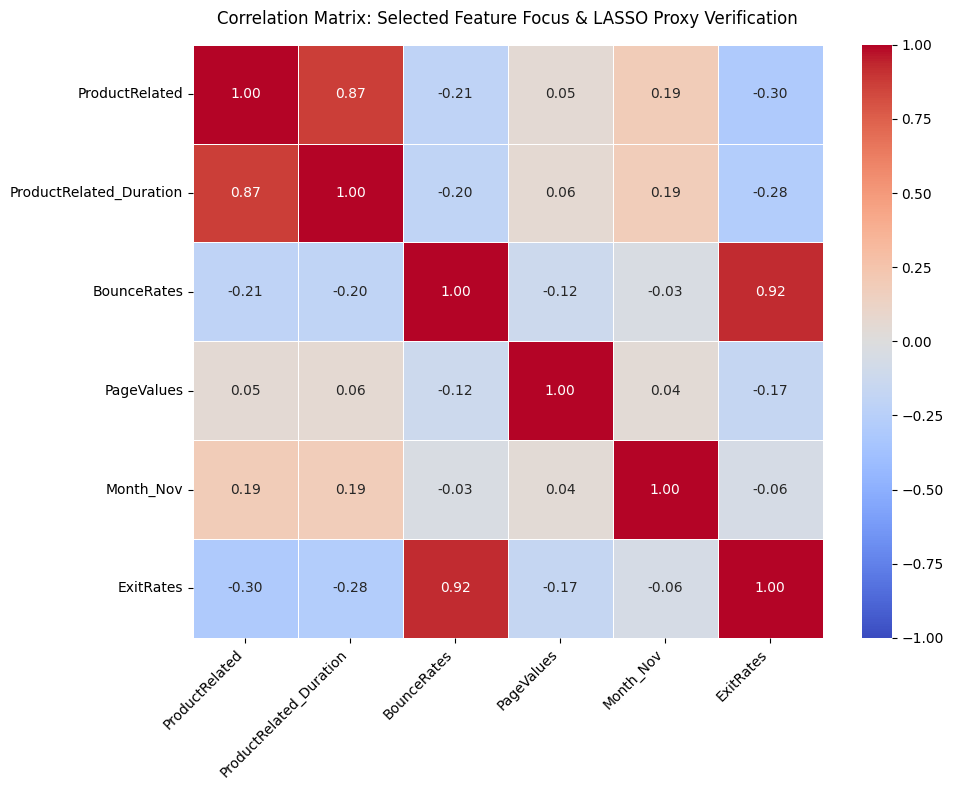

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. DEFINE TARGET FEATURES FOR MULTICOLLINEARITY ANALYSIS
# Includes the core predictors selected by LASSO across Model A and Model B 
# to empirically verify the proxy relationship between ExitRates and BounceRates.
feature_da_mappare = ['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'Month_Nov', 'ExitRates']


# 2. COMPUTE PEARSON CORRELATION MATRIX
# Calculates the pairwise Pearson correlation coefficients on the baseline training set
# prior to any LASSO transformations or dimensionality reduction steps.
matrice_corr = X_train_A[feature_da_mappare].corr()

# 3. HEATMAP CONFIGURATION AND VISUALIZATION
# Generates a standard diagnostic heatmap to visually audit the linear dependencies.
plt.figure(figsize=(10, 8))

sns.heatmap(
    matrice_corr, 
    annot=True,          # Overlay the exact numerical Pearson coefficients inside each cell
    cmap='coolwarm',     # Diverging color palette: blue (negative), white (neutral), red (positive)
    vmin=-1,             # Fix lower bound of the correlation index to represent perfect negative correlation
    vmax=1,              # Fix upper bound of the correlation index to represent perfect positive correlation
    fmt=".2f",           # Format coefficients to exactly two decimal places for readability
    linewidths=0.5       # Introduce a subtle boundary line between cells to enhance scannability
)

# Set chart metadata and adjust label rotations to prevent text overlapping
plt.title('Correlation Matrix: Selected Feature Focus & LASSO Proxy Verification', fontsize=12, pad=15)
plt.xticks(rotation=45, ha='right') # Rotate x-axis feature labels by 45 degrees for optimal alignment
plt.tight_layout()                  # Automatically adjust subplot parameters to fit within the figure area
plt.show()

A profound positive correlation of $r = 0.92$ exists between BounceRates and ExitRates. Because the LASSO (L1) regularization penalty mathematically minimizes redundant parameters to ensure structural sparsity, it naturally selects only one dominant attrition metric (retaining ExitRates in Model A). When ExitRates is manually removed from the feature pool, the L1 layer immediately selects BounceRates as its direct mathematical proxy. This collinear redundancy explains why the SVM's final test metrics remain entirely stable across both experimental setups.

## Section 3: Clustering-Based Analysis
In this section, we transition to an unsupervised learning setup where we compare different clustering algorithms to find the best performing one.

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

def get_Ncounts(y_predict, y_true, k, j=None):
    N = y_predict.shape[0]
    Nk_mask = (y_predict == k)
    Nk = Nk_mask.sum()
    Nj, Nkj = None, None
    if j is not None:
        Nj_mask = (y_true == j)
        Nj = Nj_mask.sum()
        Nkj = np.logical_and(Nk_mask, Nj_mask).sum()
    return N, Nk, Nj, Nkj

def precision(y_predict, y_true, k, j):
    _, Nk, _, Nkj = get_Ncounts(y_predict, y_true, k, j)
    return Nkj / (Nk + 1e-8)

def purity(y_predict, y_true, k):
    cls = np.unique(y_true)
    prec = [precision(y_predict, y_true, k, j) for j in cls]
    return max(prec)

def tot_purity(y_predict, y_true):
    N = y_true.shape[0]
    # Handle possible outlier classes (-1 in DBSCAN) gracefully
    valid_clusters = [c for c in np.unique(y_predict) if c != -1]
    
    p = 0
    for k in valid_clusters:
        _, Nk, _, _ = get_Ncounts(y_predict, y_true, k)
        pk = purity(y_predict, y_true, k)
        p += (Nk / N) * pk
    return p

print("Lab evaluation metrics successfully loaded.")

Lab evaluation metrics successfully loaded.


### 3.1 Feature Scaling and Multi-Algorithm Training (K=2)
Clustering algorithms rely heavily on distance calculations. Without standardization, features with large scales (such as durations) distort spatial groupings. This block standardizes the dataset and fits **$K$-Means**, **Hierarchical Agglomerative Clustering**, and **DBSCAN**.

In this section we only use **numerical features** because $K$-means and similar algorithms compute geometrical distances between data points and for this reason they don't work really well with categorical variables.
This decision is further enforced from the fact that the selected features for classification automatically exluded most of the categoical features.

Feature totali originarie: 68
Feature usate per il clustering (senza ExitRates): 9
Features attive: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

=== UNSUPERVISED CLUSTERING TRAINING (TRAINING SET) ===

K-Means++            -> Clustering Purity: 0.8442 | Silhouette Score: 0.4787


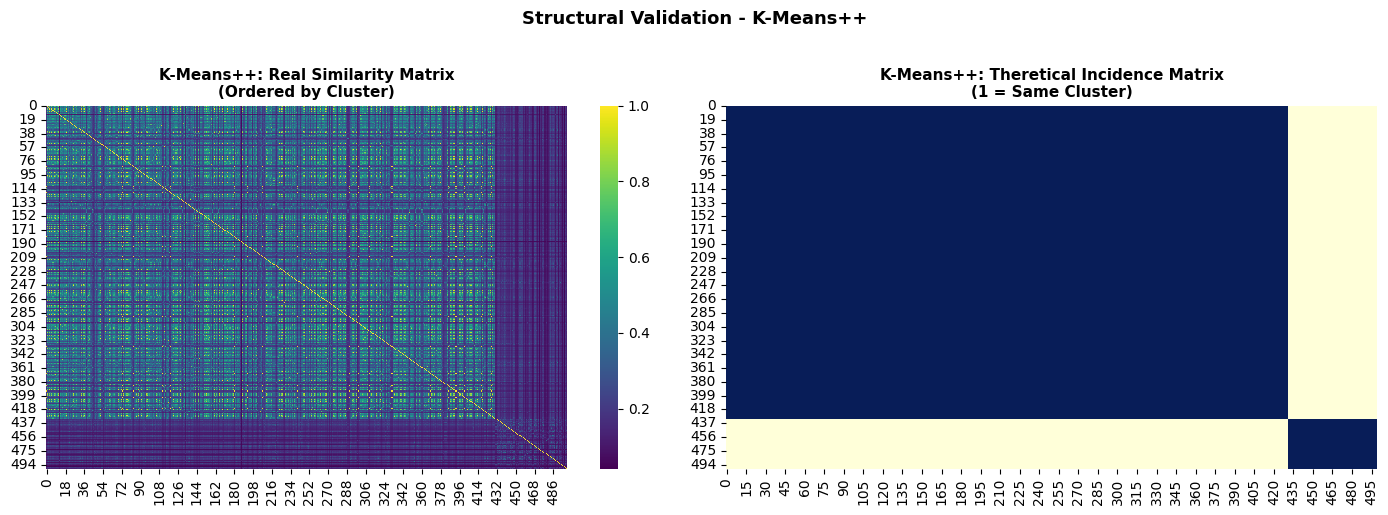


Hierarchical (Ward)  -> Clustering Purity: 0.8442 | Silhouette Score: 0.3041


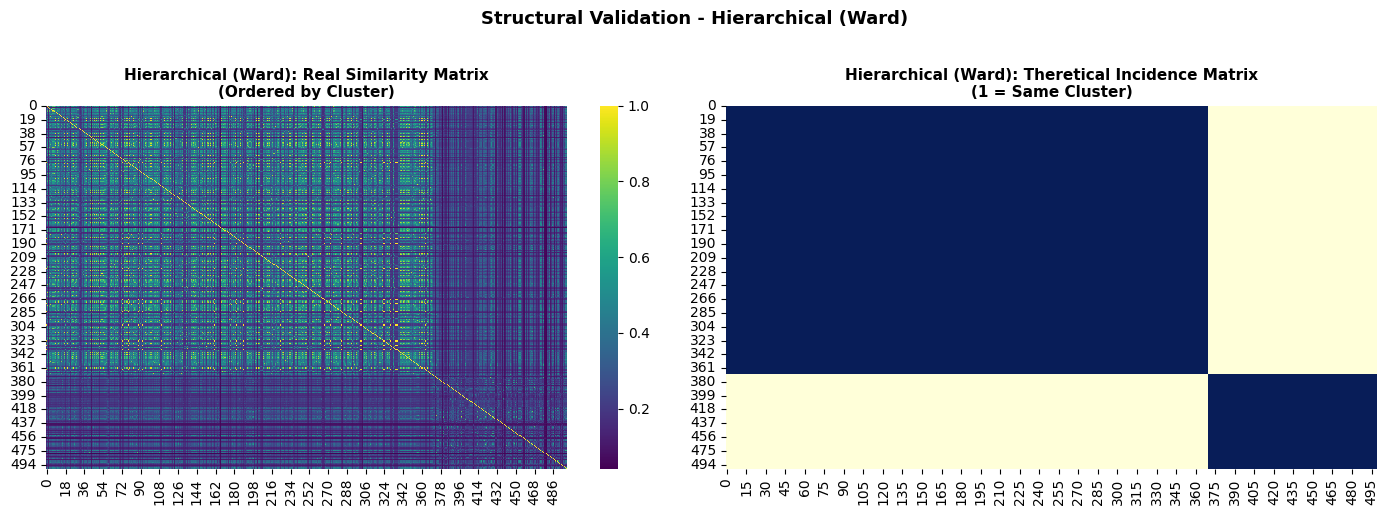


DBSCAN               -> Clustering Purity: 0.8315 | Silhouette Score: 0.6944


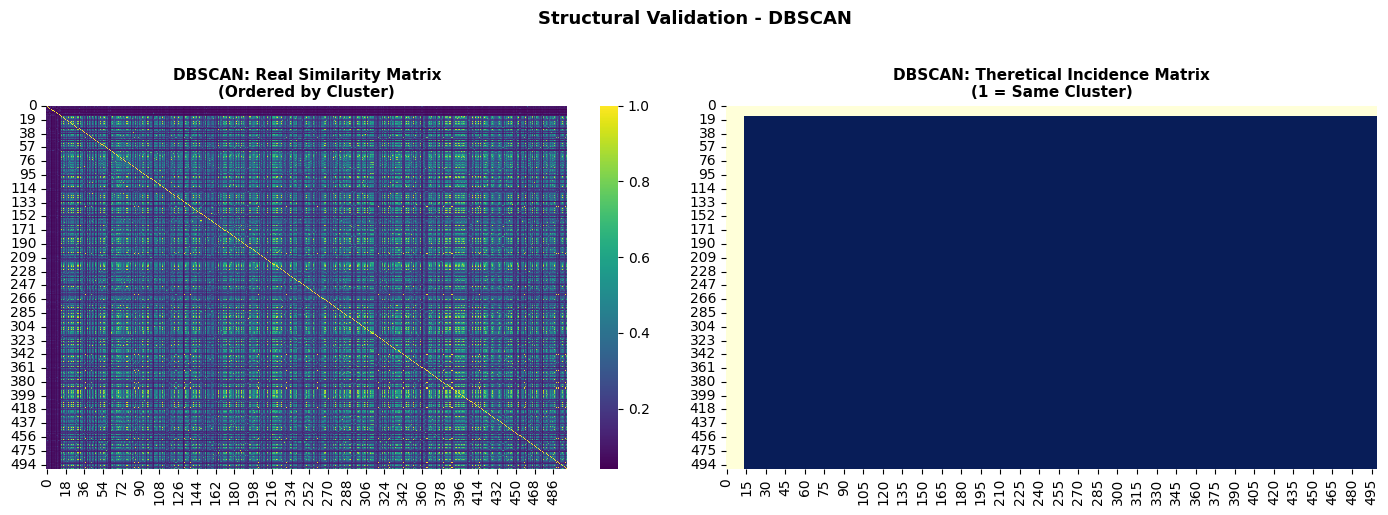



=== CLUSTERING GENERALIZATION ASSESSMENT (TEST SET) ===
K-Means++            -> Out-of-Sample Purity: 0.8485
Hierarchical (Ward)  -> Out-of-Sample Purity: 0.8485
DBSCAN               -> Out-of-Sample Purity: 0.8284


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances

features_clustering = [feat for feat in numerical_features if feat != 'ExitRates']

print(f"Feature totali originarie: {len(all_features_hot)}")
print(f"Feature usate per il clustering (senza ExitRates): {len(features_clustering)}")
print(f"Features attive: {numerical_features}\n")

##########################
# 1. Scale features
##########################
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(t_df[features_clustering])
X_test_scaled = scaler.transform(test_df[features_clustering])

# Convert y targets to explicit integer arrays
y_train_arr = y_train.values
y_test_arr = y_test.values

####################################################
# 2. Configure Clustering Implementations
####################################################
clustering_algorithms = {
    'K-Means++': KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42),
    'Hierarchical (Ward)': AgglomerativeClustering(n_clusters=2, linkage='ward'),
    'DBSCAN': DBSCAN(eps=2.5, min_samples=15)
}

print("=== UNSUPERVISED CLUSTERING TRAINING (TRAINING SET) ===")
train_results = {}
preds_kmeans = None
for name, algo in clustering_algorithms.items():
    train_preds = algo.fit_predict(X_train_scaled)
    
    # Calculate performance scores
    purity_score = tot_purity(train_preds, y_train_arr)
    sil = silhouette_score(X_train_scaled, train_preds) if len(np.unique(train_preds)) > 1 else 0.0
    
    train_results[name] = train_preds
    print(f"\n{name:20} -> Clustering Purity: {purity_score:.4f} | Silhouette Score: {sil:.4f}")
    
    df_mat_temp = pd.DataFrame(X_train_scaled).copy()
    df_mat_temp['Cluster'] = train_preds
    
    # Sampling of 500 points (to avoid memory crashes and readable graphs)
    n_sample = 500
    if len(df_mat_temp) > n_sample:
        df_sample = df_mat_temp.sample(n=n_sample, random_state=42)
    else:
        df_sample = df_mat_temp.copy()
        
    # Sorting for Cluster for chessboard effect
    df_sample = df_sample.sort_values(by='Cluster')
    
    # Extracting data for the matrices
    X_sample_scaled = df_sample.drop(columns=['Cluster']).values
    labels_sample = df_sample['Cluster'].values
    
    # A. SIMILARITY MATRIX
    dist_matrix = euclidean_distances(X_sample_scaled, X_sample_scaled)
    similarity_matrix = 1 / (1 + dist_matrix)
    
    # B. INCIDENCE MATRIX
    n_punti = len(labels_sample)
    incidence_matrix = np.zeros((n_punti, n_punti))
    for i in range(n_punti):
        for j in range(n_punti):
            if labels_sample[i] == labels_sample[j]:
                # If on the same cluster assign 1 (we exclude DBSCAN -1 as noise)
                if labels_sample[i] != -1: 
                    incidence_matrix[i, j] = 1.0
    
    # Drawing te panel for the current model
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap Real similarity
    sns.heatmap(similarity_matrix, cmap='viridis', ax=ax1, cbar=True)
    ax1.set_title(f'{name}: Real Similarity Matrix\n(Ordered by Cluster)', fontsize=11, fontweight='bold')
    ax1.grid(False)
    
    # Heatmap Theoretical incidence
    sns.heatmap(incidence_matrix, cmap='YlGnBu', ax=ax2, cbar=False)
    ax2.set_title(f'{name}: Theretical Incidence Matrix\n(1 = Same Cluster)', fontsize=11, fontweight='bold')
    ax2.grid(False)
    
    plt.suptitle(f"Structural Validation - {name}", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60 + "\n")

##############################################################################
# 3. Assess Out-of-Sample Clustering Consistency (Test Set)
##############################################################################
print("=== CLUSTERING GENERALIZATION ASSESSMENT (TEST SET) ===")
for name, algo in clustering_algorithms.items():
    if name == 'DBSCAN' or name == 'Hierarchical (Ward)':
        test_preds = algo.fit_predict(X_test_scaled)
    else:
        test_preds = algo.predict(X_test_scaled)
        preds_kmeans = test_preds
        
    test_purity = tot_purity(test_preds, y_test_arr)
    print(f"{name:20} -> Out-of-Sample Purity: {test_purity:.4f}")

The best model for the project is **K-means++** for these reasons:
 
1. It forces segmentation neatly dividing users in 2 categories ("High" and "Low" interaction users).
This is more useful for marketing studies.
 
2. Good silhouette.
A score of $0.4787$ on real and homogenous data of web navigation show that the two clusters have a good geometric separation.
 
3. K-means++ is the only model between the three to find centroids.
On test data, K-Means++ assigns the new points to the specific cluster referred by the centroids in a coherent way (***.predict()***).
Hierachical Clustering and DBSCAN do not work in the same way, and have to process the new data again (***.fit_predict()***), meaning that the cluster found on test data could have a different logical meaning to the ones in the training data.
 

### 3.2 Dimensionality Reduction and 2D Projection Visualization

To visualize the results on a 2D plane we have to use a Dimensionality Reduction technique (**PCA**) that enables to project the original data on a two dimensional plane.

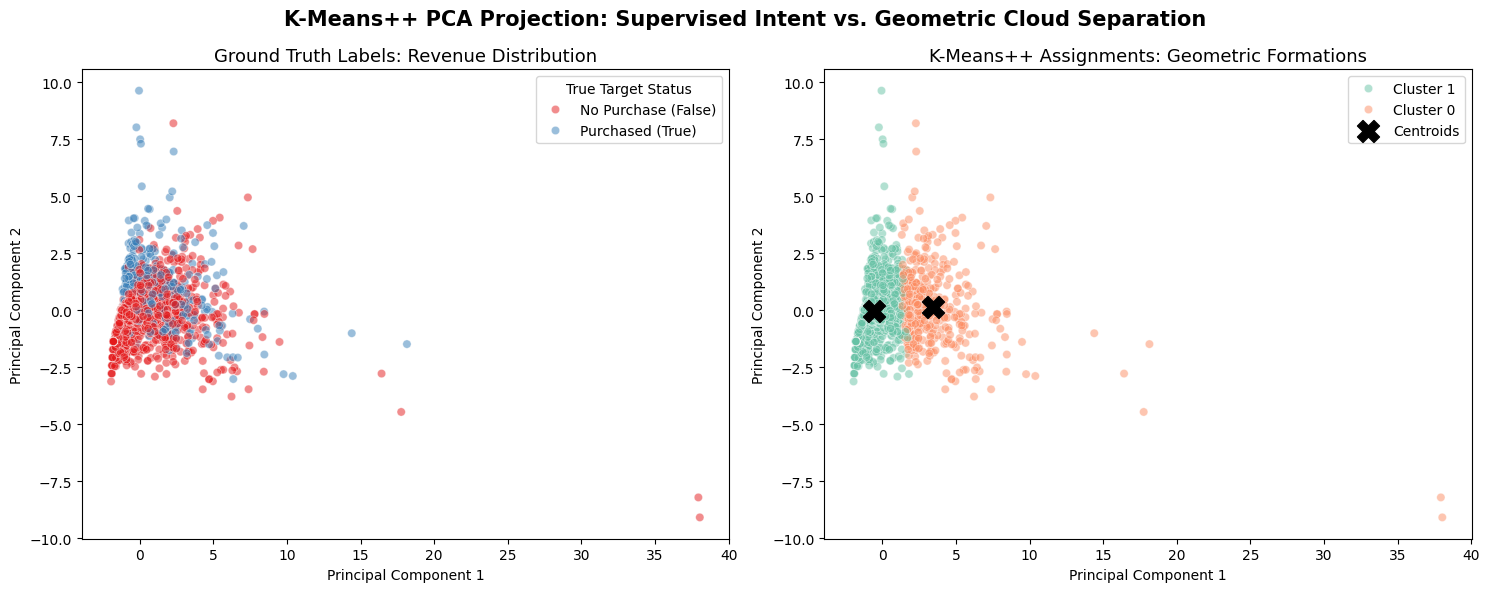


STATISTICS FOR: K-MEANS++
Total Samples Processed: 3082
PCA Variance Captured (2D): 51.28%
---------------------------------------------
Cluster Breakdown:
 - Cluster 0: 445 samples
 - Cluster 1: 2637 samples



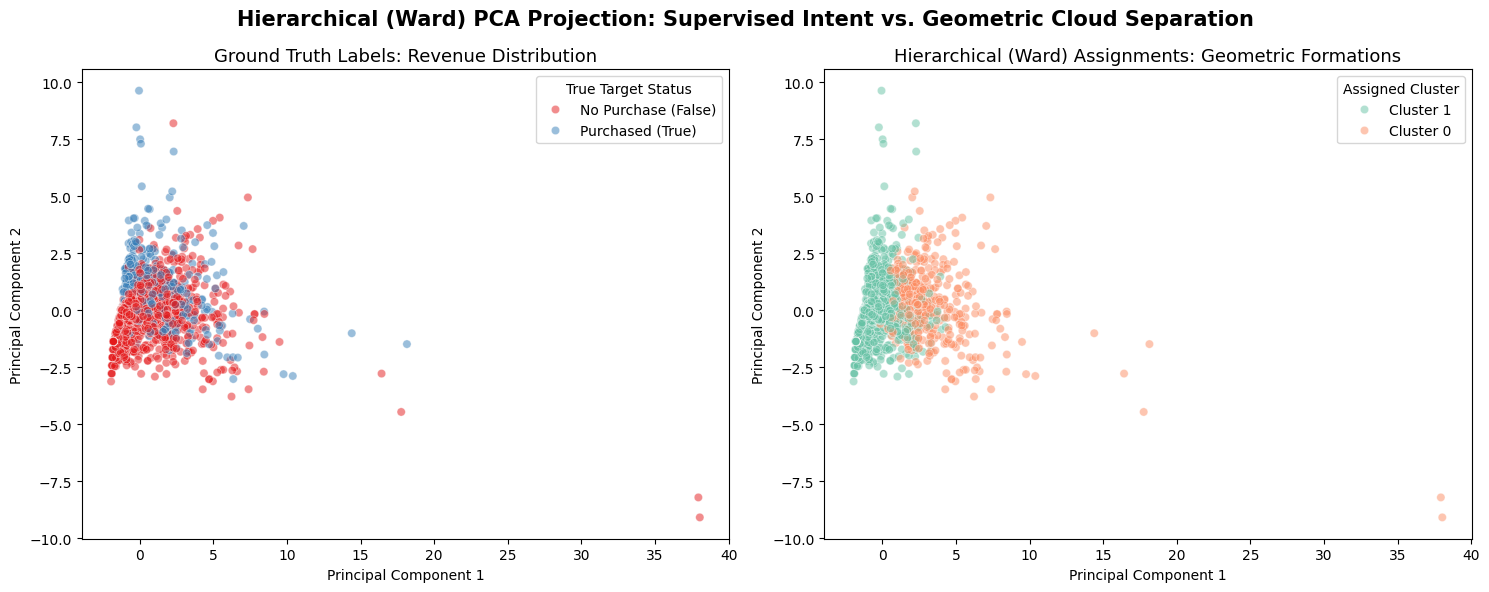


STATISTICS FOR: HIERARCHICAL (WARD)
Total Samples Processed: 3082
PCA Variance Captured (2D): 51.28%
---------------------------------------------
Cluster Breakdown:
 - Cluster 0: 499 samples
 - Cluster 1: 2583 samples



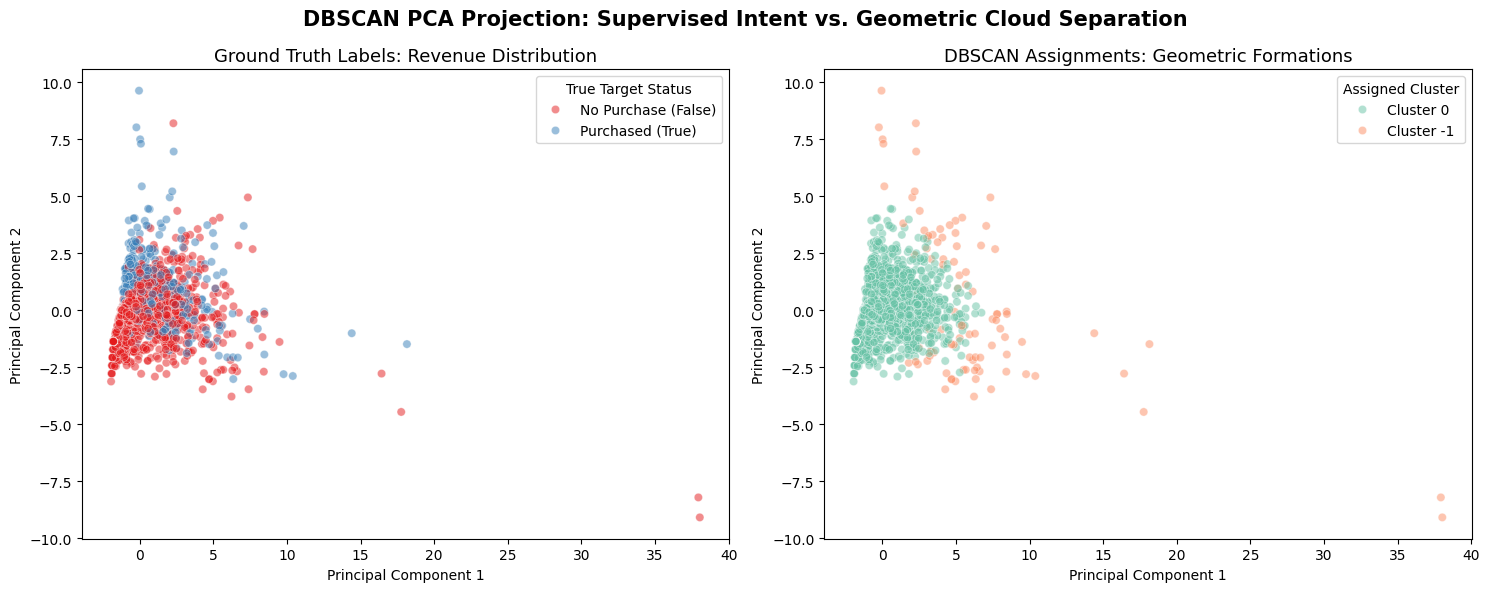


STATISTICS FOR: DBSCAN
Total Samples Processed: 3082
PCA Variance Captured (2D): 51.28%
---------------------------------------------
Cluster Breakdown:
 - Cluster -1 (Noise/Outliers): 97 samples
 - Cluster 0: 2985 samples



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Compress test features into 2 Principal Components for mapping
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

for name, alg in clustering_algorithms.items():

    cluster_preds = alg.fit_predict(X_test_scaled)

    # 2. Package coordinates and variables into a graphing frame
    pca_df = pd.DataFrame({
        'PCA Coordinate 1': X_test_pca[:, 0],
        'PCA Coordinate 2': X_test_pca[:, 1],
        'True Target Status': np.where(y_test_arr == 1, 'Purchased (True)', 'No Purchase (False)'),
        'Assigned Cluster': [f"Cluster {c}" for c in cluster_preds]
    })

    # 3. Render side-by-side comparative graphics
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot A: True Labels
    sns.scatterplot(
        data=pca_df, x='PCA Coordinate 1', y='PCA Coordinate 2', 
        hue='True Target Status', palette='Set1', ax=axes[0], alpha=0.5
    )
    axes[0].set_title('Ground Truth Labels: Revenue Distribution', fontsize=13)
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')

    # Plot B: Unsupervised Spatial Groupings
    sns.scatterplot(
        data=pca_df, x='PCA Coordinate 1', y='PCA Coordinate 2', 
        hue='Assigned Cluster', palette='Set2', ax=axes[1], alpha=0.5
    )
    
    # Only project and plot centroids if the algorithm supports them (e.g., KMeans)
    if hasattr(alg, 'cluster_centers_'):
        centroids_pca = pca.transform(alg.cluster_centers_)
        axes[1].scatter(
            centroids_pca[:, 0], centroids_pca[:, 1], 
            c='black', s=250, marker='X', label='Centroids'
        )
        axes[1].legend()

    axes[1].set_title(f'{name} Assignments: Geometric Formations', fontsize=13)
    axes[1].set_xlabel('Principal Component 1')
    axes[1].set_ylabel('Principal Component 2') 

    plt.suptitle(f'{name} PCA Projection: Supervised Intent vs. Geometric Cloud Separation', fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    print(f"\n" + "="*45)
    print(f"STATISTICS FOR: {name.upper()}")
    print(f"="*45)
    
    # Overall Dataset Stats
    print(f"Total Samples Processed: {len(X_test_scaled)}")
    print(f"PCA Variance Captured (2D): {pca.explained_variance_ratio_.sum() * 100:.2f}%")
    print(f"-"*45)
    
    # Cluster Breakdown
    print("Cluster Breakdown:")
    unique_clusters, counts = np.unique(cluster_preds, return_counts=True)
    
    for cluster_id, count in zip(unique_clusters, counts):
        # Special formatting to highlight DBSCAN noise points clearly
        if cluster_id == -1:
            print(f" - Cluster {cluster_id} (Noise/Outliers): {count} samples")
        else:
            print(f" - Cluster {cluster_id}: {count} samples")
            
    print("="*45 + "\n")

Web navigation data alone is not linearly separable in two distinct groups.
A supervised learning model predicts `Revenue` with higher accuracy because it has a target feature while cluster models have to **infer** an information from a homogeneous cloud of information and is not able to distinguish between the users that buy and those who don't.
 
The comparative analysis shows that the unsupervised grouping of data (**Clustering**) reflects really closely the distribution of the supervised target.
The graphs show that $K$-Means is the most effective technique. The captured Variance of $51.28%$ shows that a better projection would need more principal components to represent better the original data.

### 3.3 Section Insights & Interpretation
1. **Supervised vs. Unsupervised Structural Performance Gap**:
    The top-performing supervised models from Section $2$ systematically outperform unsupervised clustering pipelines. This is due to the fact that supervised models adjust their algorithmic feature weights to specifically minimize decision separation error relative to the `Revenue` label. Unsupervised algorithms evaluate the dataset grouping users based on shared properties rather than a singular target. 

2. **Behavioral Geometry vs. Purchase Status**:
    The clustering purity score reflects how much class mixing occurs inside individual spatial zones. While K-Means forms crisp geometric regions, the visual PCA scatterplots reveal that converted shoppers do not form an isolated, independent island. Instead, purchasing instances are embedded inside a high-density cluster of non-purchasing trajectories, highlighting why geometric distance boundaries alone cannot cleanly isolate a target variable as highly imbalanced as `Revenue`.

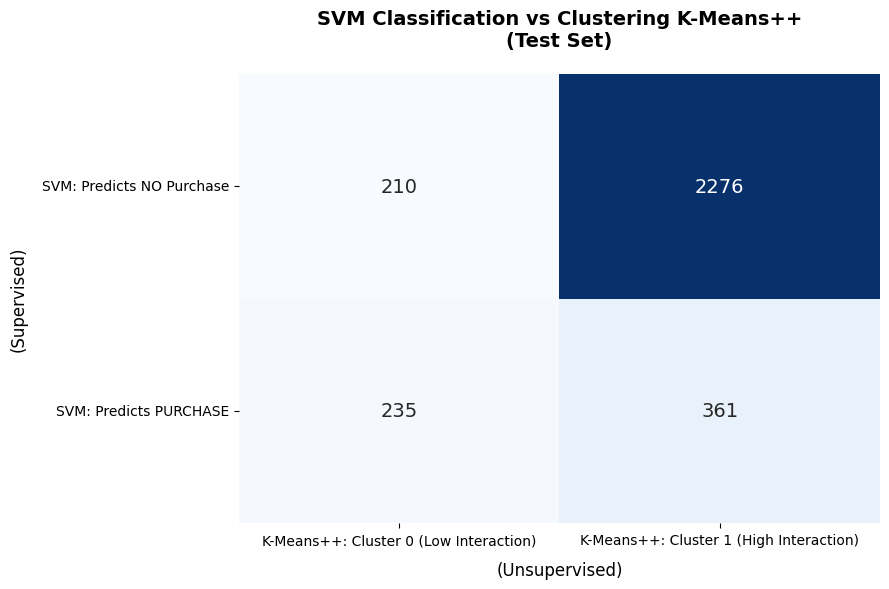

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =====================================================================
# 1. PREDICTION GENERATION ON TEST SET
# =====================================================================
# We extract the pipeline of the best model
svm_pipeline_ottima = fitted_grids['SVM'].best_estimator_

# Supervised Learning predictions (True/False <----> Purchase/No Purchase)
preds_svm = svm_pipeline_ottima.predict(X_test_A)

# Non supervised Clustering (Cluster 0 / 1)
# For K-Means we use 'X_test_scaled' (WITHOUT ExitRates)
preds_kmeans = clustering_algorithms['K-Means++'].predict(X_test_scaled)

# =====================================================================
# 2. CROSS MATRIX (CONTINGENCY)
# =====================================================================
# We cross prediction vectors of the two models
matrice_ibrida = confusion_matrix(preds_svm, preds_kmeans)

# We convert it on a daataframe
df_heatmap = pd.DataFrame(
    matrice_ibrida, 
    index=['SVM: Predicts NO Purchase', 'SVM: Predicts PURCHASE'],
    columns=['K-Means++: Cluster 0 (Low Interaction)', 'K-Means++: Cluster 1 (High Interaction)']
)

# =====================================================================
# 3. DRAWING THE HEATMAP
# =====================================================================
plt.figure(figsize=(9, 6))
sns.heatmap(df_heatmap, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})

plt.title('SVM Classification vs Clustering K-Means++\n(Test Set)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('(Unsupervised)', fontsize=12, labelpad=10)
plt.ylabel('(Supervised)', fontsize=12, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

The confusion matrix on the test set confirms that SVM (Supervised) and $K$-means (Unsupervised) share $2276$ NO PURCHASE and $235$ PURCHASE common elements.
This shows that this clustering model can be used for a pretty reliable user behaviour detection.  